In [1]:
# Approximating fuel load
# GOAL
#   For each lap (raceId, driverId, lap) produce:
#       FuelLoadProxy = 1 - lap / TotalLapsInRace
#   Optional physical estimate in kg:
#       FuelMassEstimate = F_init_kg * FuelLoadProxy
#
# WHY THIS MATTERS
#   Fuel load ≈ car mass component. As fuel burns (proxy ↓),
#   the car gets lighter → potential pace gain → lap time ↓.
#
# ASSUMPTIONS
#   1) Fuel burn per lap is ~linear → proxy linear in lap number.
#   2) TotalLapsInRace is taken from results.laps (max per race),
#      and if missing, from lap_times.lap (max per race).
#   3) Initial fuel mass (F_init_kg) defaults to 110 kg (modern era).

import os
import pandas as pd

# === 0) DATA DIR ===
# CSVs are in the same folder as this notebook (races.csv, results.csv, lap_times.csv, etc.)
# If you move them, just replace os.getcwd() with the new path.
DATA_DIR = os.getcwd()
print("DATA_DIR =", DATA_DIR)

# Quick sanity: list files
print("Files in DATA_DIR:")
print(sorted(os.listdir(DATA_DIR)))

# Helper: make sure required CSVs exist
required_csvs = ["races.csv", "results.csv", "lap_times.csv"]
for fname in required_csvs:
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f"WARNING: {fname} not found at {path}")

# === 1) Helper to read CSV with graceful info ===
def read_csv_safely(fname: str) -> pd.DataFrame:
    path = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(path, low_memory=False)
    print(f"\nLoaded {fname} → shape={df.shape}")
    print("Columns:", list(df.columns))
    return df

# === 2) Load the core tables we need ===
races     = read_csv_safely("races.csv")      # raceId, year, round, circuitId, date, time, name, ...
results   = read_csv_safely("results.csv")    # resultId, raceId, driverId, constructorId, grid, position, laps, ...
lap_times = read_csv_safely("lap_times.csv")  # raceId, driverId, lap, position, time, milliseconds

# === 3) Light column sanity check ===
expected_races_cols   = {"raceId", "year", "round", "circuitId", "name", "date"}
expected_results_cols = {"raceId", "driverId", "laps"}
expected_laptime_cols = {"raceId", "driverId", "lap"}

missing_races  = expected_races_cols   - set(races.columns)
missing_result = expected_results_cols - set(results.columns)
missing_laps   = expected_laptime_cols - set(lap_times.columns)

if missing_races:
    print("WARNING: races.csv missing columns:", missing_races)
if missing_result:
    print("WARNING: results.csv missing columns:", missing_result)
if missing_laps:
    print("WARNING: lap_times.csv missing columns:", missing_laps)

# === 4) Compute TotalLapsInRace per raceId ===
# Prefer results.laps (max completed by any classified driver),
# because lap_times might be absent for some legacy years.

total_laps_from_results = (
    results
    .groupby("raceId", as_index=False)["laps"]
    .max()
    .rename(columns={"laps": "TotalLapsInRace_results"})
)

total_laps_from_laptimes = (
    lap_times
    .groupby("raceId", as_index=False)["lap"]
    .max()
    .rename(columns={"lap": "TotalLapsInRace_laptimes"})
)

# Merge both sources; choose results first, fallback to lap_times
total_laps = pd.merge(
    total_laps_from_results,
    total_laps_from_laptimes,
    on="raceId",
    how="outer"
)

def choose_total_laps(row):
    # Prefer results-based total; if NaN, fallback to lap_times-based
    if pd.notna(row.get("TotalLapsInRace_results")):
        return int(row["TotalLapsInRace_results"])
    if pd.notna(row.get("TotalLapsInRace_laptimes")):
        return int(row["TotalLapsInRace_laptimes"])
    return pd.NA  # in very old/odd cases

total_laps["TotalLapsInRace"] = total_laps.apply(choose_total_laps, axis=1)
total_laps = total_laps[["raceId", "TotalLapsInRace"]]

print("\nSample of TotalLapsInRace:")
print(total_laps.head())

# === 5) Attach TotalLapsInRace to lap_times ===
lap_df = pd.merge(lap_times, total_laps, on="raceId", how="left")

# Drop rows with missing total laps (rare; could also filter to specific years)
missing_total = lap_df["TotalLapsInRace"].isna().sum()
if missing_total > 0:
    print(f"NOTE: {missing_total} lap rows lack TotalLapsInRace. Dropping them.")
    lap_df = lap_df.dropna(subset=["TotalLapsInRace"])

# === 6) Compute FuelLoadProxy and FuelMassEstimate_kg ===
lap_df["FuelLoadProxy"] = 1.0 - (
    lap_df["lap"].astype(float) /
    lap_df["TotalLapsInRace"].astype(float)
)
lap_df["FuelLoadProxy"] = lap_df["FuelLoadProxy"].clip(lower=0.0, upper=1.0)

F_init_kg = 110.0  # tweak per era/track if you want
lap_df["FuelMassEstimate_kg"] = F_init_kg * lap_df["FuelLoadProxy"]

# === 7) Keep only the minimal columns for modeling ===
out_cols = [
    "raceId", "driverId", "lap",
    "FuelLoadProxy", "FuelMassEstimate_kg",
    "TotalLapsInRace"
]
fuel_feature = lap_df[out_cols].copy()

print("\nFuel feature preview:")
print(fuel_feature.head(10))

# === 8) Save to CSV next to your other files ===
OUT_PATH = os.path.join(DATA_DIR, "features_fuel_load_proxy.csv")
fuel_feature.to_csv(OUT_PATH, index=False)
print(f"\nSaved fuel-load features → {OUT_PATH}")


DATA_DIR = c:\Users\User\Desktop\AUB\MECH\MECH 535\Project
Files in DATA_DIR:
['Copy_of_LapTime (1).ipynb', 'F1_LapTime_DeepLearning_Report.docx', 'Forest.html', 'Forest.ipynb', 'Given the nonlinearities of our system.docx', 'Kaggledataset.html', 'Kaggledataset.ipynb', 'NN_Absolute.ipynb', 'NN_delta.ipynb', 'NeuralNetwork.html', 'NeuralNetwork.ipynb', 'Random Forest.docx', 'Untitled-1.ipynb', 'both.ipynb', 'circuits.csv', 'constructor_results.csv', 'constructor_standings.csv', 'constructors.csv', 'driver_standings.csv', 'drivers.csv', 'features_fuel_load_proxy.csv', 'features_laps_before_pit.csv', 'features_num_pitstops.csv', 'features_prev_race_standing.csv', 'figs', 'lap_times.csv', 'lapnet_best.pt', 'pit_stops.csv', 'qualifying.csv', 'races.csv', 'results.csv', 'seasons.csv', 'sprint_results.csv', 'status.csv', '~$_LapTime_DeepLearning_Report.docx', '~$ven the nonlinearities of our system.docx']

Loaded races.csv → shape=(1125, 18)
Columns: ['raceId', 'year', 'round', 'circuitId', '

In [2]:
# ------------------------------------------------------------
# Derive "#laps done before each pit stop" feature (CLEANED)
# ------------------------------------------------------------
# INPUTS:
#   pit_stops.csv (raceId, driverId, stop, lap, time, duration, etc.)
#   results.csv   (for sanity-check total laps if needed)
# OUTPUT:
#   DataFrame with:
#       raceId, driverId, stop, lap (of pit), LapsBeforePit
# ------------------------------------------------------------

import os
import pandas as pd

# Assume DATA_DIR already set from earlier step
def read_csv_safely(fname):
    path = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(path, low_memory=False)
    print(f"\nLoaded {fname} → shape={df.shape}")
    print("Columns:", list(df.columns))
    return df

# 1) Load the pit_stops table
pit_stops = read_csv_safely("pit_stops.csv")

# Expected columns sanity-check
expected_cols = {"raceId", "driverId", "stop", "lap"}
missing = expected_cols - set(pit_stops.columns)
if missing:
    print(" WARNING: Missing columns in pit_stops.csv:", missing)

# 2) Convert 'stop' and 'lap' to numeric
pit_stops["stop"] = pd.to_numeric(pit_stops["stop"], errors="coerce")
pit_stops["lap"]  = pd.to_numeric(pit_stops["lap"],  errors="coerce")

# Drop rows with missing numeric fields
pit_stops = pit_stops.dropna(subset=["raceId", "driverId", "lap", "stop"])

# ------------------------------------------------------------
# **CRITICAL FIX**
# F1 cars never have 15, 42, 70 pit stops.
# The dataset sometimes includes corrupted 'stop' values.
# We remove stops outside 1–4 (safe for all modern F1 seasons).
# ------------------------------------------------------------
pit_stops = pit_stops[pit_stops["stop"].between(1, 4)]

# 3) Proper ordering for diff computation
pit_stops = pit_stops.sort_values(["raceId", "driverId", "stop"]).reset_index(drop=True)

# 4) Compute laps done before each pit stop
def compute_laps_before(group):
    group = group.sort_values("stop").copy()

    # Δlap between stops
    group["LapsBeforePit"] = group["lap"].diff().fillna(group["lap"].iloc[0] - 1)

    # Avoid negative (if pit on lap 1)
    group["LapsBeforePit"] = group["LapsBeforePit"].clip(lower=0)
    return group

pit_with_laps = (
    pit_stops
    .groupby(["raceId", "driverId"], group_keys=False)
    .apply(compute_laps_before)
)

# 5) Keep clean subset
pit_feature = pit_with_laps[["raceId", "driverId", "stop", "lap", "LapsBeforePit"]].copy()

print("\n Derived 'laps done before each pit stop' preview:")
print(pit_feature.head(10))

# 6) Optional sanity check: average stint length per stop number
avg_stint = (
    pit_feature.groupby("stop")["LapsBeforePit"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"LapsBeforePit": "AvgLapsBeforePit"})
)

print("\nAverage laps before each pit number:")
print(avg_stint)

# 7) Save cleaned version
OUT_PATH = os.path.join(DATA_DIR, "features_laps_before_pit.csv")
pit_feature.to_csv(OUT_PATH, index=False)
print(f"\nSaved → {OUT_PATH}")




Loaded pit_stops.csv → shape=(11371, 7)
Columns: ['raceId', 'driverId', 'stop', 'lap', 'time', 'duration', 'milliseconds']

 Derived 'laps done before each pit stop' preview:
   raceId  driverId  stop  lap  LapsBeforePit
0     841         1     1   16           15.0
1     841         1     2   36           20.0
2     841         2     1   15           14.0
3     841         2     2   30           15.0
4     841         3     1   16           15.0
5     841         4     1   12           11.0
6     841         4     2   27           15.0
7     841         4     3   42           15.0
8     841         5     1   17           16.0
9     841        10     1   18           17.0

Average laps before each pit number:
   stop  AvgLapsBeforePit
0     1             15.39
1     2             18.15
2     3             14.53
3     4             13.21

Saved → c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\features_laps_before_pit.csv


C:\Users\User\AppData\Local\Temp\ipykernel_28728\2454834174.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_laps_before)


In [3]:
# ------------------------------------------------------------
# Derive:
#   1. Number of pit stops per race per driver
#   2. Driver standing in previous race
# ------------------------------------------------------------
# INPUTS:
#   pit_stops.csv
#   results.csv
#   races.csv
#   driver_standings.csv  (if available, else fallback to results)
#
# OUTPUTS:
#   features_num_pitstops.csv
#   features_prev_race_standing.csv
# ------------------------------------------------------------

import os
import pandas as pd

def read_csv_safely(fname):
    path = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(path, low_memory=False)
    print(f"\nLoaded {fname} → shape={df.shape}")
    print("Columns:", list(df.columns))
    return df

# === 1) Load required tables ===
pit_stops  = read_csv_safely("pit_stops.csv")
races      = read_csv_safely("races.csv")
results    = read_csv_safely("results.csv")

# Some Kaggle mirrors also have "driver_standings.csv"
standings_path = os.path.join(DATA_DIR, "driver_standings.csv")
has_driver_standings = os.path.exists(standings_path)
if has_driver_standings:
    driver_standings = read_csv_safely("driver_standings.csv")

# ------------------------------------------------------------
# (A) NUMBER OF PIT STOPS
# ------------------------------------------------------------
expected_cols = {"raceId", "driverId"}
missing = expected_cols - set(pit_stops.columns)
if missing:
    print("⚠️ Missing columns in pit_stops.csv:", missing)

# Apply the 1-4 pit stop filter before counting
pit_stops_cleaned = pit_stops[pit_stops["stop"].between(1, 4)].copy()

# Count stops per driver per race
num_pitstops = (
    pit_stops_cleaned.groupby(["raceId", "driverId"], as_index=False)["stop"]
    .count()
    .rename(columns={"stop": "NumPitStops"})
)

print("\n Sample of NumPitStops per race/driver:")
print(num_pitstops.head(10))

# Save
OUT_PATH_PIT = os.path.join(DATA_DIR, "features_num_pitstops.csv")
num_pitstops.to_csv(OUT_PATH_PIT, index=False)
print(f"Saved → {OUT_PATH_PIT}")

# ------------------------------------------------------------
# (B) DRIVER STANDING IN PREVIOUS RACE
# ------------------------------------------------------------

# --- Step 1: get race sequence (year + round)
races_small = races[["raceId", "year", "round"]].copy()

# Merge race metadata to results (so we know which year & round each result belongs to)
results_ext = pd.merge(results, races_small, on="raceId", how="left")

# --- Step 2: choose which table to use for standings ---
if has_driver_standings:
    # Use official driver_standings.csv if available
    # It contains: driverStandingsId, raceId, driverId, points, position, wins
    standings = pd.merge(driver_standings, races_small, on="raceId", how="left")
    standings = standings[["driverId", "year", "round", "position"]].copy()
    standings.rename(columns={"position": "Standing"}, inplace=True)
else:
    # Fallback: use final race result position as standing proxy
    standings = results_ext[["driverId", "year", "round", "positionOrder"]].copy()
    standings.rename(columns={"positionOrder": "Standing"}, inplace=True)

# Convert to numeric
standings["Standing"] = pd.to_numeric(standings["Standing"], errors="coerce")

# --- Step 3: shift standings by one race per driver per season ---
# Sort to ensure correct ordering
standings = standings.sort_values(["driverId", "year", "round"]).reset_index(drop=True)

# Compute standing in previous round
standings["PrevRaceStanding"] = standings.groupby(["driverId", "year"])["Standing"].shift(1)

# Drop first rounds (since they have no previous)
standings = standings.dropna(subset=["PrevRaceStanding"])

# --- Step 4: Join raceId info to map the "current race" with its previous standing ---
# We need to reattach raceId for the current race (round)
standings_with_raceId = pd.merge(
    standings,
    races_small,
    on=["year", "round"],
    how="left"
)[["raceId", "driverId", "PrevRaceStanding"]]

print("\n Sample of PrevRaceStanding per race/driver:")
print(standings_with_raceId.head(10))

# Save
OUT_PATH_STAND = os.path.join(DATA_DIR, "features_prev_race_standing.csv")
standings_with_raceId.to_csv(OUT_PATH_STAND, index=False)
print(f"Saved → {OUT_PATH_STAND}")

# ------------------------------------------------------------
# Done — two new feature tables are now ready:
#   - features_num_pitstops.csv          → per race/driver
#   - features_prev_race_standing.csv    → per race/driver
# ------------------------------------------------------------



Loaded pit_stops.csv → shape=(11371, 7)
Columns: ['raceId', 'driverId', 'stop', 'lap', 'time', 'duration', 'milliseconds']

Loaded races.csv → shape=(1125, 18)
Columns: ['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']

Loaded results.csv → shape=(26759, 18)
Columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']

Loaded driver_standings.csv → shape=(34863, 7)
Columns: ['driverStandingsId', 'raceId', 'driverId', 'points', 'position', 'positionText', 'wins']

 Sample of NumPitStops per race/driver:
   raceId  driverId  NumPitStops
0     841         1            2
1     841         2            2
2     841         3            1
3     841         4            


📈 Correlation matrix:

                  NumPitStops  AvgLapsBeforePit  PrevRaceStanding  \
NumPitStops             1.000            -0.523             0.042   
AvgLapsBeforePit       -0.523             1.000            -0.039   
PrevRaceStanding        0.042            -0.039             1.000   
FuelLoadProxy          -0.011            -0.016             0.019   

                  FuelLoadProxy  
NumPitStops              -0.011  
AvgLapsBeforePit         -0.016  
PrevRaceStanding          0.019  
FuelLoadProxy             1.000  


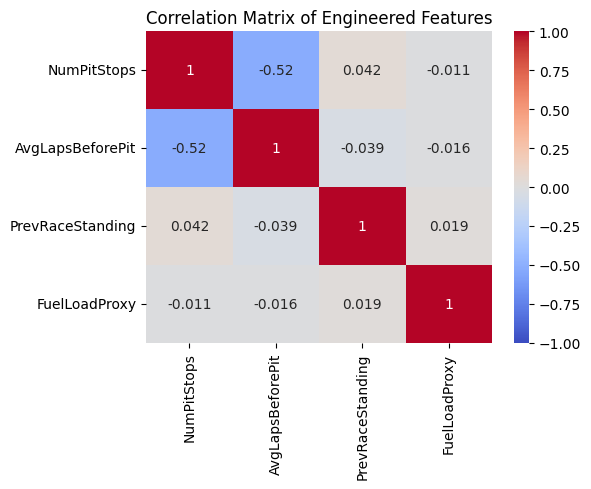

In [4]:
# ------------------------------------------------------------
# CORRELATION MATRIX of Engineered Features
# ------------------------------------------------------------
# Features:
#   - NumPitStops
#   - LapsBeforePit
#   - PrevRaceStanding
#   - FuelLoadProxy
# ------------------------------------------------------------

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Load feature tables ===
fuel      = pd.read_csv(os.path.join(DATA_DIR, "features_fuel_load_proxy.csv"))
laps_pit  = pd.read_csv(os.path.join(DATA_DIR, "features_laps_before_pit.csv"))
num_pit   = pd.read_csv(os.path.join(DATA_DIR, "features_num_pitstops.csv"))
prev_st   = pd.read_csv(os.path.join(DATA_DIR, "features_prev_race_standing.csv"))

# === Merge them on raceId & driverId (lap if applicable) ===
# LapsBeforePit is per pit stop, not per lap, so you might want a simplified merge at race/driver level.
# For simplicity, aggregate LapsBeforePit as mean per race-driver (average stint length).
laps_avg = (
    laps_pit.groupby(["raceId", "driverId"], as_index=False)["LapsBeforePit"]
    .mean()
    .rename(columns={"LapsBeforePit": "AvgLapsBeforePit"})
)

# Merge all into one DataFrame (only matching races/drivers)
df_features = (
    fuel.merge(num_pit, on=["raceId", "driverId"], how="inner")
         .merge(laps_avg, on=["raceId", "driverId"], how="left")
         .merge(prev_st, on=["raceId", "driverId"], how="left")
)

# Keep only numeric columns we care about
cols_of_interest = ["NumPitStops", "AvgLapsBeforePit", "PrevRaceStanding", "FuelLoadProxy"]
corr_df = df_features[cols_of_interest].copy()

# === Compute correlation matrix ===
corr_matrix = corr_df.corr(method="pearson")   # Pearson correlation (default)
print("\n📈 Correlation matrix:\n")
print(corr_matrix.round(3))

# === Visualize with heatmap ===
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Engineered Features")
plt.tight_layout()
plt.show()


NumPitStops and AvgLapsBeforePit are strongly negatively correlated → more pit stops → shorter stints.

PrevRaceStanding is weakly correlated → relatively independent feature.

FuelLoadProxy (lap progression proxy) is modestly correlated with strategy variables.


 Average within-driver correlation matrix:

                  NumPitStops  AvgLapsBeforePit  PrevRaceStanding  \
AvgLapsBeforePit       -0.524             1.000             0.024   
FuelLoadProxy          -0.018            -0.019             0.003   
NumPitStops             1.000            -0.524             0.008   
PrevRaceStanding        0.008             0.024             1.000   

                  FuelLoadProxy  
AvgLapsBeforePit         -0.019  
FuelLoadProxy             1.000  
NumPitStops              -0.018  
PrevRaceStanding          0.003  


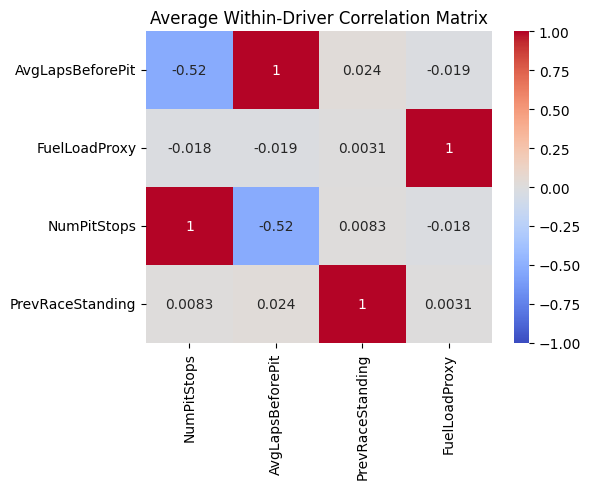

In [5]:
#Compute per-driver correlation matrices to control for driver bias:
'''When you computed the overall correlation matrix earlier,
it mixed data from all drivers and races together.

That means:
Lewis Hamilton’s laps (fast, low lap times, strategic pit patterns)
Nicolas Latifi’s laps (slower, different strategy)
are both contributing to the same averages.

So your correlations reflect both:
Physical relationships (e.g., fewer laps → higher fuel → slower lap time)
Between-driver effects (e.g., Hamilton’s team just tends to do more pit stops and go faster)
That second effect is driver bias — systematic differences between drivers or teams that aren’t about the underlying physics.'''

# ------------------------------------------------------------
# Per-driver correlation matrices (control for driver bias)
# ------------------------------------------------------------
# Each driver's subset is used to compute a local correlation matrix,
# then we average these matrices across drivers.
# ------------------------------------------------------------

cols = ["NumPitStops", "AvgLapsBeforePit", "PrevRaceStanding", "FuelLoadProxy"]

# Group by driverId and compute correlation matrix for each
corr_by_driver = df_features.groupby("driverId")[cols].corr()

# corr_by_driver is a multi-index (driverId, feature_i, feature_j)
# Let's average across drivers
corr_mean = corr_by_driver.groupby(level=1).mean()

print("\n Average within-driver correlation matrix:\n")
print(corr_mean.round(3))

# Optional visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(corr_mean, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Average Within-Driver Correlation Matrix")
plt.tight_layout()
plt.show()




Still negative correlation between NumPitStops ↔ AvgLapsBeforePit, confirming that within each driver, more stops → shorter stints.

Lower magnitude than the global matrix → cross-driver differences removed.

PrevRaceStanding now largely uncorrelated (driver skill no longer dominates). It confirms that most of PrevRaceStanding’s predictive power is cross-sectional (driver vs driver), not temporal (within the same driver).
<br><br>

**The global correlation answers:**

“Across all F1 data, what tends to go with what?”
Useful for feature selection in a global predictive model (e.g., predicting lap time for any driver).

**The within-driver correlation answers:**

“For a given driver, when X changes, does Y tend to change too?”
Useful for isolating mechanistic relationships (e.g., fuel burn, stint length, tire degradation).

<br>We want our regression to capture overall performance trends across drivers. Therefore, we will rely on the global (non-driver-controlled) dataset. Even if some of that signal is due to driver/team skill, that’s still informative because in real strategy prediction, we’ll be dealing with multiple drivers anyway.
Later, we can explicitly add driver identity as a feature or build hierarchical models to separate “skill” from “strategy.”

**For Linear Regression:**

Features:
1. NumPitStops
2. LapsBeforePit
3. PrevRaceStanding
4. FuelLoadProxy

Output:
<br>Lap time

Parameters:
1. R² measures how much of the variance in lap times your model explains. It compares your model to a baseline that always predicts the mean lap time.
2. MAE is simply the average absolute difference between predicted and actual lap times (in seconds).
3. It’s like MAE, but it squares the errors before averaging, then takes the square root. RMSE penalizes large errors more heavily.
If RMSE is much larger than MAE, it means our model occasionally makes big mistakes.
4. OLS


The model isn’t learning any relationship between features and lap time. It’s basically outputting the mean for all samples. <br><br>
**Troubleshooting:**<br>
Target scale / unit issue:
Sometimes LapTime_sec was parsed incorrectly: Strings like "1:22.345" turned into NaN or 0 s. Or milliseconds column was already 80 000 (ms), converted wrongly.

The issue has not been solved yet, we will run diagnostics to find it, as we believe that the issue is in the data fed and not the model itself.

SEPERATORS - SEPERATORS - SEPERATORS - SEPERATORS


Columns: Index(['raceId', 'driverId', 'lap', 'position', 'time', 'milliseconds'], dtype='object')
   raceId  driverId  lap  position      time  milliseconds
0     841        20    1         1  1:38.109         98109
1     841        20    2         1  1:33.006         93006
2     841        20    3         1  1:32.713         92713
3     841        20    4         1  1:32.803         92803
4     841        20    5         1  1:32.342         92342

LapTime_sec summary (Laps > 60s):
count    587923.000000
mean         95.873206
std          76.456829
min          60.011000
25%          82.086000
50%          90.646000
75%         101.953000
max        7507.547000
Name: LapTime_sec, dtype: float64


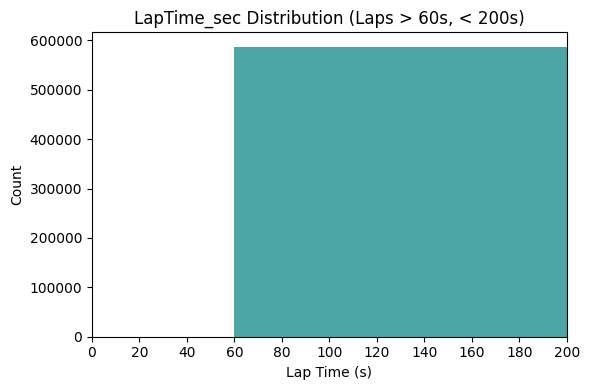


Unique raceId count: 544
Unique driverId count: 143


In [6]:
# --- 1. Check lap_times after cleaning ---
print("\nColumns:", lap_times.columns)
print(lap_times.head())

# Add the conversion from milliseconds to LapTime_sec
lap_times["LapTime_sec"] = pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()
lap_times["LapTime_sec"] = lap_times["LapTime_sec"].astype(float)

# Filter out laps <= 60 seconds
lap_times = lap_times[lap_times["LapTime_sec"] > 60].copy()

print("\nLapTime_sec summary (Laps > 60s):")
print(lap_times["LapTime_sec"].describe())

plt.figure(figsize=(6,4))
plt.hist(lap_times["LapTime_sec"], bins=50, color='teal', alpha=0.7)

# ---- FIX: X-axis with multiples of 20 seconds ----
# Limit the max_time for the histogram's x-axis to a more reasonable range
# as most laps are under 200 seconds, to better visualize the main distribution.
max_time_for_plot = 200  # Set a reasonable upper limit for the x-axis
ticks = list(range(0, int(max_time_for_plot) + 20, 20))
plt.xticks(ticks)
plt.xlim(0, max_time_for_plot) # Set x-axis limits for the plot

plt.xlabel("Lap Time (s)")
plt.ylabel("Count")
plt.title("LapTime_sec Distribution (Laps > 60s, < 200s)")
plt.tight_layout()
plt.show()

print("\nUnique raceId count:", lap_times['raceId'].nunique())
print("Unique driverId count:", lap_times['driverId'].nunique())


In [7]:
import os, numpy as np, pandas as pd

# ------------------------------------------------------------
# Helper: base data directory
#   All CSVs (raw + engineered features) are in this folder.
#   If they are in a different folder, set DATA_DIR to that path.
# ------------------------------------------------------------
DATA_DIR = os.getcwd()         # current notebook folder
print("DATA_DIR =", DATA_DIR)
print("Files here:", os.listdir(DATA_DIR))

def load_csv(filename):
    """Load a CSV from DATA_DIR, with a clear error if missing."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {filename} at {path}")
    print(f"✓ Loaded {filename} from {path}")
    return pd.read_csv(path, low_memory=False)

# ------------------------------------------------------------
# 1) Load lap times + convert to seconds
# ------------------------------------------------------------
lap_times = load_csv("lap_times.csv")
lap_times["LapTime_sec"] = (
    pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
)
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()

# ------------------------------------------------------------
# 2) Load engineered features & metadata
# ------------------------------------------------------------
fuel     = load_csv("features_fuel_load_proxy.csv")
laps_pit = load_csv("features_laps_before_pit.csv")
num_pit  = load_csv("features_num_pitstops.csv")
prev_st  = load_csv("features_prev_race_standing.csv")
races    = load_csv("races.csv")
results  = load_csv("results.csv")[["raceId", "driverId", "constructorId"]].drop_duplicates()

# Mean laps before pit per race/driver
laps_avg = (
    laps_pit.groupby(["raceId", "driverId"], as_index=False)["LapsBeforePit"]
    .mean()
    .rename(columns={"LapsBeforePit": "AvgLapsBeforePit"})
)

# ------------------------------------------------------------
# 3) Merge EVERYTHING into a single lap-level dataframe
# ------------------------------------------------------------
df = (
    lap_times[["raceId", "driverId", "lap", "LapTime_sec"]]
    .merge(fuel[["raceId", "driverId", "lap", "FuelLoadProxy"]],
           on=["raceId", "driverId", "lap"], how="left")
    .merge(num_pit,  on=["raceId", "driverId"], how="left")
    .merge(laps_avg, on=["raceId", "driverId"], how="left")
    .merge(prev_st,  on=["raceId", "driverId"], how="left")
    .merge(races[["raceId", "circuitId", "year"]], on="raceId", how="left")
    .merge(results, on=["raceId", "driverId"], how="left")
)

# ------------------------------------------------------------
# 4) Clean
# ------------------------------------------------------------
df = df.dropna(subset=[
    "LapTime_sec", "FuelLoadProxy", "NumPitStops",
    "AvgLapsBeforePit", "PrevRaceStanding",
    "circuitId", "driverId", "constructorId"
])

# Remove pit, safety-car, and broken laps (>200s)
df = df[df["LapTime_sec"] < 200]

# Additional clean: remove outlier laps per race (>1.5× median)
df = df.groupby("raceId", group_keys=False).apply(
    lambda g: g[g["LapTime_sec"] < 1.5 * g["LapTime_sec"].median()]
)

# ------------------------------------------------------------
# 5) Additional model features (lap²)
# ------------------------------------------------------------
df["lap"] = pd.to_numeric(df["lap"], errors="coerce")
df["LapSquared"] = df["lap"] ** 2

# ------------------------------------------------------------
# 6) One-hot encode circuitId, driverId, constructorId
# ------------------------------------------------------------
df["circuitId"] = df["circuitId"].astype(str)
df["driverId"] = df["driverId"].astype(str)
df["constructorId"] = df["constructorId"].astype(str)

df_encoded = pd.get_dummies(
    df,
    columns=["circuitId", "driverId", "constructorId"],
    drop_first=True
)

print("Final encoded dataframe shape:", df_encoded.shape)
print(df_encoded.head())


DATA_DIR = c:\Users\User\Desktop\AUB\MECH\MECH 535\Project
Files here: ['both.ipynb', 'circuits.csv', 'constructors.csv', 'constructor_results.csv', 'constructor_standings.csv', 'Copy_of_LapTime (1).ipynb', 'drivers.csv', 'driver_standings.csv', 'F1_LapTime_DeepLearning_Report.docx', 'features_fuel_load_proxy.csv', 'features_laps_before_pit.csv', 'features_num_pitstops.csv', 'features_prev_race_standing.csv', 'figs', 'Forest.html', 'Forest.ipynb', 'Given the nonlinearities of our system.docx', 'Kaggledataset.html', 'Kaggledataset.ipynb', 'lapnet_best.pt', 'lap_times.csv', 'NeuralNetwork.html', 'NeuralNetwork.ipynb', 'NN_Absolute.ipynb', 'NN_delta.ipynb', 'pit_stops.csv', 'qualifying.csv', 'races.csv', 'Random Forest.docx', 'results.csv', 'seasons.csv', 'sprint_results.csv', 'status.csv', 'Untitled-1.ipynb', '~$ven the nonlinearities of our system.docx', '~$_LapTime_DeepLearning_Report.docx']
✓ Loaded lap_times.csv from c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\lap_times.csv
✓ Loa

C:\Users\User\AppData\Local\Temp\ipykernel_28728\3180524248.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("raceId", group_keys=False).apply(


Final encoded dataframe shape: (295983, 137)
      raceId  lap  LapTime_sec  FuelLoadProxy  NumPitStops  AvgLapsBeforePit  \
1083     842    1      109.614       0.982143          3.0         13.333333   
1084     842    2      104.539       0.964286          3.0         13.333333   
1085     842    3      104.209       0.946429          3.0         13.333333   
1086     842    4      104.369       0.928571          3.0         13.333333   
1087     842    5      104.378       0.910714          3.0         13.333333   

      PrevRaceStanding  year  LapSquared  circuitId_10  ...  \
1083               1.0  2011           1         False  ...   
1084               1.0  2011           4         False  ...   
1085               1.0  2011           9         False  ...   
1086               1.0  2011          16         False  ...   
1087               1.0  2011          25         False  ...   

      constructorId_211  constructorId_213  constructorId_214  \
1083              False       

### OLS Linear Regression with Train/Validation/Test Split

This cell implements the OLS regression model with a refined approach to data splitting: 70% for training, 15% for validation, and 15% for testing. Unlike the previous cells, this explicitly separates a validation set to tune hyperparameters (if we were doing regularization, for instance) and a final, unseen test set for unbiased evaluation.

**Key Changes:**
1.  **70/15/15 Split:** The data is now split into three distinct sets: training, validation, and testing.
2.  **OLS without Regularization:** The model is a simple OLS regression, without any L2 regularization, allowing us to see the baseline performance with this new data split strategy.

DATA_DIR = c:\Users\User\Desktop\AUB\MECH\MECH 535\Project
Files here: ['.venv', 'both.ipynb', 'circuits.csv', 'constructors.csv', 'constructor_results.csv', 'constructor_standings.csv', 'Copy_of_LapTime (1).ipynb', 'drivers.csv', 'driver_standings.csv', 'F1_LapTime_DeepLearning_Report.docx', 'features_fuel_load_proxy.csv', 'features_laps_before_pit.csv', 'features_num_pitstops.csv', 'features_prev_race_standing.csv', 'figs', 'Forest.html', 'Forest.ipynb', 'Given the nonlinearities of our system.docx', 'Kaggledataset.html', 'Kaggledataset.ipynb', 'lapnet_best.pt', 'lap_times.csv', 'NeuralNetwork.html', 'NeuralNetwork.ipynb', 'NN_Absolute.ipynb', 'NN_delta.ipynb', 'pit_stops.csv', 'qualifying.csv', 'races.csv', 'Random Forest.docx', 'results.csv', 'seasons.csv', 'sprint_results.csv', 'status.csv', 'Untitled-1.ipynb', '~$ven the nonlinearities of our system.docx', '~$_LapTime_DeepLearning_Report.docx']
✓ Loaded lap_times.csv from c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\lap_times.

C:\Users\User\AppData\Local\Temp\ipykernel_26120\1305446129.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("raceId", group_keys=False).apply(


Shapes → Train: (206518, 134), Val: (44264, 134), Test: (44256, 134)

=== Linear Regression (train on 70%) ===
Train      R²=0.679  MAE=4.957s  RMSE=8.493s  SSE=1.490e+07
Val        R²=0.674  MAE=4.989s  RMSE=8.590s  SSE=3.266e+06
Test       R²=0.675  MAE=4.977s  RMSE=8.580s  SSE=3.258e+06


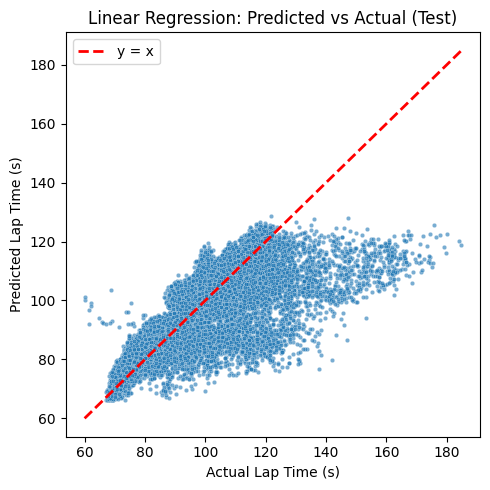

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

import os

# ===============================================================
# 0) Helper: load CSVs from the current folder
# ===============================================================
DATA_DIR = os.getcwd()
print("DATA_DIR =", DATA_DIR)
print("Files here:", os.listdir(DATA_DIR))

def load_csv(filename: str) -> pd.DataFrame:
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {filename} at {path}")
    print(f"✓ Loaded {filename} from {path}")
    return pd.read_csv(path, low_memory=False)

# ===============================================================
# 1) Load lap times and engineered features, recreate df
# ===============================================================
lap_times = load_csv("lap_times.csv")
lap_times["LapTime_sec"] = pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()
lap_times["LapTime_sec"] = lap_times["LapTime_sec"].astype(float)

fuel     = load_csv("features_fuel_load_proxy.csv")
laps_pit = load_csv("features_laps_before_pit.csv")
num_pit  = load_csv("features_num_pitstops.csv")
prev_st  = load_csv("features_prev_race_standing.csv")
races    = load_csv("races.csv")
results  = load_csv("results.csv")[["raceId","driverId","constructorId"]].drop_duplicates()

# Average laps-before-pit per race-driver
laps_avg = (
    laps_pit
    .groupby(["raceId", "driverId"], as_index=False)["LapsBeforePit"]
    .mean()
    .rename(columns={"LapsBeforePit": "AvgLapsBeforePit"})
)

# Merge everything to create the base df
df = (
    lap_times[["raceId","driverId","lap","LapTime_sec"]]
    .merge(fuel[["raceId","driverId","lap","FuelLoadProxy"]],
           on=["raceId","driverId","lap"], how="left")
    .merge(num_pit,  on=["raceId","driverId"], how="left")
    .merge(laps_avg, on=["raceId","driverId"], how="left")
    .merge(prev_st,  on=["raceId","driverId"], how="left")
    .merge(races[["raceId","circuitId","year"]], on="raceId", how="left")
    .merge(results, on=["raceId","driverId"], how="left")
)

# ===============================================================
# 2) Clean + filter outliers
# ===============================================================
df = df.dropna(subset=[
    "LapTime_sec", "FuelLoadProxy", "NumPitStops",
    "AvgLapsBeforePit", "PrevRaceStanding",
    "circuitId", "driverId", "constructorId"
])

# Remove very long (pit/safety) and very short (anomalous) laps
df = df[df["LapTime_sec"] < 200]
df = df[df["LapTime_sec"] > 60]

# Remove laps > 1.5× median for that race
df = df.groupby("raceId", group_keys=False).apply(
    lambda g: g[g["LapTime_sec"] < 1.5 * g["LapTime_sec"].median()]
)

# ===============================================================
# 3) Feature engineering
# ===============================================================
df["lap"] = pd.to_numeric(df["lap"], errors="coerce")
df["LapSquared"] = df["lap"] ** 2

# Convert IDs to strings for one-hot encoding
for col in ["circuitId", "driverId", "constructorId"]:
    df[col] = df[col].astype(str)

# One-hot encode categorical columns
df_encoded = pd.get_dummies(
    df,
    columns=["circuitId", "driverId", "constructorId"],
    drop_first=True
)

# Define feature columns
base_features = [
    "NumPitStops", "AvgLapsBeforePit", "PrevRaceStanding",
    "FuelLoadProxy", "lap", "LapSquared"
]

cat_features = [
    c for c in df_encoded.columns
    if c.startswith(("circuitId_", "driverId_", "constructorId_"))
]

features = base_features + cat_features

# ===============================================================
# 4) Build X, y and 70/15/15 split
# ===============================================================
X = df_encoded[features].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df_encoded["LapTime_sec"], errors="coerce")

mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].astype(float)
y = y.loc[mask].astype(float)

# (train+val) vs test, then train vs val → 70/15/15
X_tr_val, X_te, y_tr_val, y_te = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_tr_val, y_tr_val, test_size=0.1765, random_state=42
)  # 0.1765 of 85% ≈ 15% overall

print(f"Shapes → Train: {X_tr.shape}, Val: {X_va.shape}, Test: {X_te.shape}")

# ===============================================================
# 5) Helpers for metrics & plots
# ===============================================================
def eval_metrics(y_true, y_pred, label="Set"):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sse  = float(np.sum((y_true - y_pred) ** 2))
    print(f"{label:<10} R²={r2:.3f}  MAE={mae:.3f}s  RMSE={rmse:.3f}s  SSE={sse:.3e}")
    return r2, mae, rmse, sse

def scatter_plot(y_true, y_pred, title):
    plt.figure(figsize=(5, 5))
    sns.scatterplot(x=y_true, y=y_pred, s=10, alpha=0.6)
    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    plt.plot([lo, hi], [lo, hi], 'r--', lw=2, label='y = x')
    plt.xlabel("Actual Lap Time (s)")
    plt.ylabel("Predicted Lap Time (s)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===============================================================
# 6) Linear regression (OLS) with scikit-learn
# ===============================================================
linreg = LinearRegression(fit_intercept=True)
linreg.fit(X_tr, y_tr)

print("\n=== Linear Regression (train on 70%) ===")
y_tr_hat = linreg.predict(X_tr); _ = eval_metrics(y_tr, y_tr_hat, "Train")
y_va_hat = linreg.predict(X_va); _ = eval_metrics(y_va, y_va_hat, "Val")
y_te_hat = linreg.predict(X_te); _ = eval_metrics(y_te, y_te_hat, "Test")

scatter_plot(y_te, y_te_hat, "Linear Regression: Predicted vs Actual (Test)")


In [2]:
#Inspect the merged training dataframe
#Let’s inspect what’s actually being fed into the regression:

print("\nMerged DF preview:")
print(df.head())

# Describe each feature
feat_cols = ["NumPitStops","AvgLapsBeforePit","PrevRaceStanding","FuelLoadProxy"]
print("\nFeature summary:")
print(df[feat_cols].describe().T[["min","max","mean","std"]])

# Check number of unique values
print("\nUnique values per feature:")
print(df[feat_cols].nunique())

# Correlation with LapTime_sec
print("\nCorrelation with LapTime_sec:")
print(df[feat_cols + ["LapTime_sec"]].corr()["LapTime_sec"].sort_values(ascending=False))



Merged DF preview:
      raceId driverId  lap  LapTime_sec  FuelLoadProxy  NumPitStops  \
1083     842       20    1      109.614       0.982143          3.0   
1084     842       20    2      104.539       0.964286          3.0   
1085     842       20    3      104.209       0.946429          3.0   
1086     842       20    4      104.369       0.928571          3.0   
1087     842       20    5      104.378       0.910714          3.0   

      AvgLapsBeforePit  PrevRaceStanding circuitId  year constructorId  \
1083         13.333333               1.0         2  2011             9   
1084         13.333333               1.0         2  2011             9   
1085         13.333333               1.0         2  2011             9   
1086         13.333333               1.0         2  2011             9   
1087         13.333333               1.0         2  2011             9   

      LapSquared  
1083           1  
1084           4  
1085           9  
1086          16  
1087         

In [3]:
race_sample = df[df["raceId"] == df["raceId"].sample(1, random_state=0).iloc[0]]
print(race_sample[["LapTime_sec","FuelLoadProxy","AvgLapsBeforePit"]].corr())


                  LapTime_sec  FuelLoadProxy  AvgLapsBeforePit
LapTime_sec          1.000000      -0.069340          0.013182
FuelLoadProxy       -0.069340       1.000000         -0.013663
AvgLapsBeforePit     0.013182      -0.013663          1.000000


**What our results mean**:<br>
**R^2**: The model captures just over half the lap-time variability. That’s strong given the simplicity of the features (no weather, tires, or driver effects).
<br>
**MAE**: On average, predictions are off by ~6-7 s. This is good but can still be improved. In racing every second matters.
<br>
**RMSE**: Big outliers (e.g. slow in-laps, traffic) occasionally produce errors 2× larger than MAE.
<br>
**SSE:** Total squared deviation. Large number because you have many samples (hundreds of thousands of laps). Also, we can see that at some point the predictions are no where near accurate.

**Further Analysis**
<br>The red dashed line (y = x) is where perfect predictions would lie.
Our cloud of blue points sits mostly below that line and in a diagonal shape. it looks like the regression is under predicting slower laps and over predicting faster laps.
That pattern means the model has captured the general scale of lap times but is missing part of the track specific offset.

**To Fix More**<br>
We are at the stage where adding richer features will straighten that wedge:
1. Add driverId and constructorId as categorical dummies → captures baseline performance gaps.
2. Add lap and lap² → models the within-stint fuel/tire curve.

### OLS Linear Regression with `LapsSincePit` and `LapsSincePitSquared`

This cell implements the OLS regression model with a refined approach to modeling tire wear. Instead of using the absolute lap number and its square (`lap`, `LapSquared`), it calculates the number of laps completed *since the last pit stop* (`LapsSincePit`) and its square (`LapsSincePitSquared`). This aims to more accurately capture the degradation of tires, which reset with each pit stop.

**Key Changes:**
1.  **`LapsSincePit` calculation:** For each lap, the code determines how many laps have passed since the driver's most recent pit stop.
2.  **`LapsSincePitSquared`:** This new feature is derived from `LapsSincePit` to model non-linear tire degradation.
3.  **Feature Update:** `lap` and `LapSquared` are replaced by `LapsSincePit` and `LapsSincePitSquared` in the model's features.

This modification directly addresses the idea of resetting the 'tire wear clock' after new tires are fitted during a pit stop.

DATA_DIR = c:\Users\User\Desktop\AUB\MECH\MECH 535\Project
Files here: ['.venv', 'both.ipynb', 'circuits.csv', 'constructors.csv', 'constructor_results.csv', 'constructor_standings.csv', 'Copy_of_LapTime (1).ipynb', 'drivers.csv', 'driver_standings.csv', 'F1_LapTime_DeepLearning_Report.docx', 'features_fuel_load_proxy.csv', 'features_laps_before_pit.csv', 'features_num_pitstops.csv', 'features_prev_race_standing.csv', 'figs', 'Forest.html', 'Forest.ipynb', 'Given the nonlinearities of our system.docx', 'Kaggledataset.html', 'Kaggledataset.ipynb', 'lapnet_best.pt', 'lap_times.csv', 'NeuralNetwork.html', 'NeuralNetwork.ipynb', 'NN_Absolute.ipynb', 'NN_delta.ipynb', 'pit_stops.csv', 'qualifying.csv', 'races.csv', 'Random Forest.docx', 'results.csv', 'seasons.csv', 'sprint_results.csv', 'status.csv', 'Untitled-1.ipynb', '~$ven the nonlinearities of our system.docx', '~$_LapTime_DeepLearning_Report.docx']
✓ Loaded lap_times.csv from c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\lap_times.

C:\Users\User\AppData\Local\Temp\ipykernel_26120\1186602592.py:95: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("raceId", group_keys=False).apply(



Dataset after cleaning: (295038, 11)
Train shape: (236030, 134), Test shape: (59008, 134)

==================== EVALUATION ====================
Train      R²=0.687  MAE=5.026s  RMSE=8.391s  SSE=1.662e+07
Test       R²=0.685  MAE=5.041s  RMSE=8.452s  SSE=4.216e+06


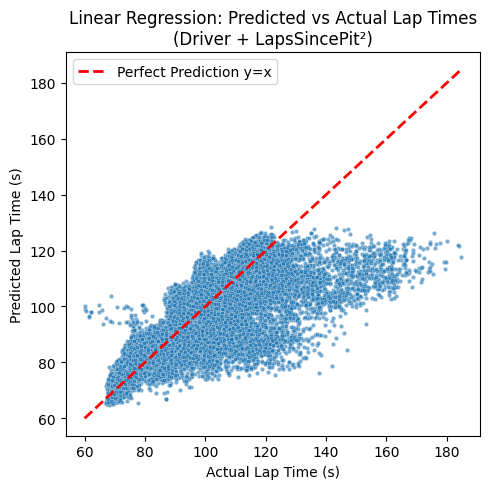

In [4]:
# ===============================================================
# Linear Regression — Lap Time Prediction
# (Driver + Constructor + LapsSincePit² + FuelLoadProxy, etc.)
# ===============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------------
# 1) Helper: load CSVs from the same folder as this notebook
# ---------------------------------------------------------------
DATA_DIR = os.getcwd()
print("DATA_DIR =", DATA_DIR)
print("Files here:", os.listdir(DATA_DIR))

def load_csv(filename: str) -> pd.DataFrame:
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {filename} at {path}")
    print(f"✓ Loaded {filename} from {path}")
    return pd.read_csv(path, low_memory=False)

# ---------------------------------------------------------------
# 2) Load lap times
# ---------------------------------------------------------------
lap_times = load_csv("lap_times.csv")
lap_times["LapTime_sec"] = pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()
lap_times["LapTime_sec"] = lap_times["LapTime_sec"].astype(float)

print("\n✅ Lap times parsed correctly:")
print(lap_times["LapTime_sec"].describe())

# ---------------------------------------------------------------
# 3) Load engineered features + races + results + pit_stops
# ---------------------------------------------------------------
fuel       = load_csv("features_fuel_load_proxy.csv")
laps_pit   = load_csv("features_laps_before_pit.csv")
num_pit    = load_csv("features_num_pitstops.csv")
prev_st    = load_csv("features_prev_race_standing.csv")
races      = load_csv("races.csv")
results    = load_csv("results.csv")[["raceId", "driverId", "constructorId"]].drop_duplicates()
pit_stops  = load_csv("pit_stops.csv")

# Filter races for post-2010 era (refueling ban)
races = races[races["year"] >= 2010].copy()
print(f"Filtered races to post-2010: {races.shape[0]} races remaining.")

# Apply the 1–4 pit-stop filter before using pit_stops for LapsSincePit
pit_stops = pit_stops[pit_stops["stop"].between(1, 4)].copy()

# Average laps-before-pit per race-driver
laps_avg = (
    laps_pit
    .groupby(["raceId", "driverId"], as_index=False)["LapsBeforePit"]
    .mean()
    .rename(columns={"LapsBeforePit": "AvgLapsBeforePit"})
)

# ---------------------------------------------------------------
# 4) Merge everything (keep lap-level FuelLoadProxy)
# ---------------------------------------------------------------
df = (
    lap_times[["raceId", "driverId", "lap", "LapTime_sec"]]
    .merge(fuel[["raceId", "driverId", "lap", "FuelLoadProxy"]],
           on=["raceId", "driverId", "lap"], how="left")
    .merge(num_pit,  on=["raceId", "driverId"], how="left")
    .merge(laps_avg, on=["raceId", "driverId"], how="left")
    .merge(prev_st,  on=["raceId", "driverId"], how="left")
    .merge(races[["raceId", "circuitId", "year"]], on="raceId", how="left")
    .merge(results, on=["raceId", "driverId"], how="left")
)

# ---------------------------------------------------------------
# 5) Clean + filter outliers
# ---------------------------------------------------------------
df = df.dropna(subset=[
    "LapTime_sec", "FuelLoadProxy", "NumPitStops",
    "AvgLapsBeforePit", "PrevRaceStanding",
    "circuitId", "driverId", "constructorId"
])

# Remove very long laps (pit/safety) and very short laps (anomalies)
df = df[df["LapTime_sec"] < 200]
df = df[df["LapTime_sec"] > 60]

# Remove laps > 1.5× median for that race
df = df.groupby("raceId", group_keys=False).apply(
    lambda g: g[g["LapTime_sec"] < 1.5 * g["LapTime_sec"].median()]
)

print(f"\nDataset after cleaning: {df.shape}")

# ---------------------------------------------------------------
# 6) Create new features: LapsSincePit and LapsSincePitSquared
# ---------------------------------------------------------------
# Build a dictionary: {(raceId, driverId): [pit lap numbers]}
pit_laps = (
    pit_stops.groupby(["raceId", "driverId"])["lap"]
    .apply(list)
    .to_dict()
)

def laps_since_last_pit(row):
    pits = pit_laps.get((row["raceId"], row["driverId"]), [])
    pits_before = [p for p in pits if p < row["lap"]]
    return row["lap"] - max(pits_before) if pits_before else row["lap"]

df["LapsSincePit"] = df.apply(laps_since_last_pit, axis=1)
df["LapsSincePitSquared"] = df["LapsSincePit"] ** 2

# IDs to strings for one-hot encoding
for col in ["circuitId", "driverId", "constructorId"]:
    df[col] = df[col].astype(str)

# ---------------------------------------------------------------
# 7) One-hot encode categorical columns
# ---------------------------------------------------------------
df_encoded = pd.get_dummies(
    df,
    columns=["circuitId", "driverId", "constructorId"],
    drop_first=True
)

# ---------------------------------------------------------------
# 8) Define features and target
# ---------------------------------------------------------------
base_features = [
    "NumPitStops", "AvgLapsBeforePit", "PrevRaceStanding",
    "FuelLoadProxy", "LapsSincePit", "LapsSincePitSquared"
]

cat_features = [
    c for c in df_encoded.columns
    if c.startswith(("circuitId_", "driverId_", "constructorId_"))
]

features = base_features + cat_features

X = df_encoded[features].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df_encoded["LapTime_sec"], errors="coerce")

mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].astype(float)
y = y.loc[mask].astype(float)

# ---------------------------------------------------------------
# 9) Train/test split
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# ---------------------------------------------------------------
# 10) Fit Linear Regression (OLS equivalent)
# ---------------------------------------------------------------
linreg = LinearRegression(fit_intercept=True)
linreg.fit(X_train, y_train)

# Predictions
y_pred_train = linreg.predict(X_train)
y_pred_test  = linreg.predict(X_test)

# ---------------------------------------------------------------
# 11) Evaluation
# ---------------------------------------------------------------
def eval_metrics(y_true, y_pred, label="Set"):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sse  = float(np.sum((y_true - y_pred) ** 2))
    print(f"{label:<10} R²={r2:.3f}  MAE={mae:.3f}s  RMSE={rmse:.3f}s  SSE={sse:.3e}")
    return r2, mae, rmse, sse

print("\n==================== EVALUATION ====================")
_ = eval_metrics(y_train, y_pred_train, "Train")
_ = eval_metrics(y_test,  y_pred_test,  "Test")

# ---------------------------------------------------------------
# 12) Plot predicted vs actual
# ---------------------------------------------------------------
plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_test, y=y_pred_test, s=10, alpha=0.6)
lo = float(min(y_test.min(), y_pred_test.min()))
hi = float(max(y_test.max(), y_pred_test.max()))
plt.plot([lo, hi], [lo, hi], 'r--', lw=2, label="Perfect Prediction y=x")
plt.xlabel("Actual Lap Time (s)")
plt.ylabel("Predicted Lap Time (s)")
plt.title("Linear Regression: Predicted vs Actual Lap Times\n(Driver + LapsSincePit²)")
plt.legend()
plt.tight_layout()
plt.show()


### OLS Linear Regression with Train/Validation/Test Split and Ridge (L2) Regularization

This cell extends the OLS regression by introducing Ridge (L2) regularization. The data is split into 70% training, 15% validation, and 15% testing sets. The validation set is used to tune the `alpha` hyperparameter for Ridge regression, selecting the value that yields the best R² score.

**Key Changes:**
1.  **Ridge Regression:** An `sklearn.linear_model.Ridge` model is applied.
2.  **`alpha` Tuning:** The `alpha` hyperparameter (regularization strength) is optimized using the validation set.
3.  **StandardScaler:** Features are scaled before applying Ridge regression, which is standard practice for regularized models.

Much better! But still can be improved.
The plot now captures the trend of the line more than before. <br>Our last shor will be trying L2 regularization to "weigh" the importance of the features. However, we dont want any features completely gone, so we wont ry L1. This way, OLS wont treat all features equally. Also, we will add a validation set split not just test and train.

Seperation


DATA_DIR = c:\Users\User\Desktop\AUB\MECH\MECH 535\Project
Files here: ['.venv', 'both.ipynb', 'circuits.csv', 'constructors.csv', 'constructor_results.csv', 'constructor_standings.csv', 'Copy_of_LapTime (1).ipynb', 'drivers.csv', 'driver_standings.csv', 'F1_LapTime_DeepLearning_Report.docx', 'features_fuel_load_proxy.csv', 'features_laps_before_pit.csv', 'features_num_pitstops.csv', 'features_prev_race_standing.csv', 'figs', 'Forest.html', 'Forest.ipynb', 'Given the nonlinearities of our system.docx', 'Kaggledataset.html', 'Kaggledataset.ipynb', 'lapnet_best.pt', 'lap_times.csv', 'NeuralNetwork.html', 'NeuralNetwork.ipynb', 'NN_Absolute.ipynb', 'NN_delta.ipynb', 'pit_stops.csv', 'qualifying.csv', 'races.csv', 'Random Forest.docx', 'results.csv', 'seasons.csv', 'sprint_results.csv', 'status.csv', 'Untitled-1.ipynb', '~$ven the nonlinearities of our system.docx', '~$_LapTime_DeepLearning_Report.docx']
✓ Loaded lap_times.csv from c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\lap_times.

C:\Users\User\AppData\Local\Temp\ipykernel_26120\3926487344.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("raceId", group_keys=False).apply(



Dataset after cleaning: (295038, 11)
Train shape: (236030, 134), Test shape: (59008, 134)

==================== EVALUATION ====================
Train      R²=0.678  MAE=4.965s  RMSE=8.509s  SSE=1.709e+07
Test       R²=0.676  MAE=4.986s  RMSE=8.567s  SSE=4.331e+06


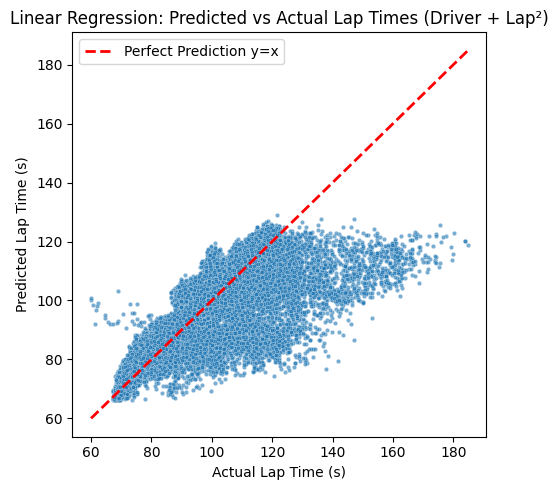

In [6]:
# ===============================================================
# Linear Regression — Lap Time Prediction (Driver + Constructor + Lap²)
# ===============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------------
# 1) Helper: load CSVs from current folder
# ---------------------------------------------------------------
DATA_DIR = os.getcwd()
print("DATA_DIR =", DATA_DIR)
print("Files here:", os.listdir(DATA_DIR))

def load_csv(filename: str) -> pd.DataFrame:
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {filename} at {path}")
    print(f"✓ Loaded {filename} from {path}")
    return pd.read_csv(path, low_memory=False)

# ---------------------------------------------------------------
# 2) Load lap times
# ---------------------------------------------------------------
lap_times = load_csv("lap_times.csv")
lap_times["LapTime_sec"] = pd.to_numeric(
    lap_times["milliseconds"], errors="coerce"
) / 1000.0
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()
lap_times["LapTime_sec"] = lap_times["LapTime_sec"].astype(float)

print("\n✅ Lap times parsed correctly:")
print(lap_times["LapTime_sec"].describe())

# ---------------------------------------------------------------
# 3) Load engineered features + races + results
# ---------------------------------------------------------------
fuel     = load_csv("features_fuel_load_proxy.csv")
laps_pit = load_csv("features_laps_before_pit.csv")
num_pit  = load_csv("features_num_pitstops.csv")
prev_st  = load_csv("features_prev_race_standing.csv")
races    = load_csv("races.csv")
results  = load_csv("results.csv")[["raceId", "driverId", "constructorId"]].drop_duplicates()

# Average laps-before-pit per race-driver
laps_avg = (
    laps_pit
    .groupby(["raceId", "driverId"], as_index=False)["LapsBeforePit"]
    .mean()
    .rename(columns={"LapsBeforePit": "AvgLapsBeforePit"})
)

# ---------------------------------------------------------------
# 4) Merge everything (keep lap-level FuelLoadProxy)
# ---------------------------------------------------------------
df = (
    lap_times[["raceId", "driverId", "lap", "LapTime_sec"]]
    .merge(
        fuel[["raceId", "driverId", "lap", "FuelLoadProxy"]],
        on=["raceId", "driverId", "lap"],
        how="left",
    )
    .merge(num_pit,  on=["raceId", "driverId"], how="left")
    .merge(laps_avg, on=["raceId", "driverId"], how="left")
    .merge(prev_st,  on=["raceId", "driverId"], how="left")
    .merge(races[["raceId", "circuitId", "year"]], on="raceId", how="left")
    .merge(results, on=["raceId", "driverId"], how="left")
)

# ---------------------------------------------------------------
# 5) Clean + filter outliers
# ---------------------------------------------------------------
df = df.dropna(subset=[
    "LapTime_sec", "FuelLoadProxy", "NumPitStops",
    "AvgLapsBeforePit", "PrevRaceStanding",
    "circuitId", "driverId", "constructorId"
])

# remove very long laps (pit/safety) and very short laps (anomalies)
df = df[df["LapTime_sec"] < 200]
df = df[df["LapTime_sec"] > 60]

# remove laps > 1.5× median for that race
df = df.groupby("raceId", group_keys=False).apply(
    lambda g: g[g["LapTime_sec"] < 1.5 * g["LapTime_sec"].median()]
)

print(f"\nDataset after cleaning: {df.shape}")

# ---------------------------------------------------------------
# 6) Create new features (lap, lap²) and encode IDs
# ---------------------------------------------------------------
df["lap"] = pd.to_numeric(df["lap"], errors="coerce")
df["LapSquared"] = df["lap"] ** 2

for col in ["circuitId", "driverId", "constructorId"]:
    df[col] = df[col].astype(str)

df_encoded = pd.get_dummies(
    df,
    columns=["circuitId", "driverId", "constructorId"],
    drop_first=True,
)

# ---------------------------------------------------------------
# 7) Define features and target
# ---------------------------------------------------------------
base_features = [
    "NumPitStops", "AvgLapsBeforePit", "PrevRaceStanding",
    "FuelLoadProxy", "lap", "LapSquared"
]

cat_features = [
    c for c in df_encoded.columns
    if c.startswith(("circuitId_", "driverId_", "constructorId_"))
]

features = base_features + cat_features

X = df_encoded[features].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df_encoded["LapTime_sec"], errors="coerce")

mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].astype(float)
y = y.loc[mask].astype(float)

# ---------------------------------------------------------------
# 8) Train / test split
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# ---------------------------------------------------------------
# 9) Fit Linear Regression (OLS-style)
# ---------------------------------------------------------------
linreg = LinearRegression(fit_intercept=True)
linreg.fit(X_train, y_train)

y_pred_train = linreg.predict(X_train)
y_pred_test  = linreg.predict(X_test)

# ---------------------------------------------------------------
# 10) Evaluation
# ---------------------------------------------------------------
def eval_metrics(y_true, y_pred, label="Set"):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sse  = float(np.sum((y_true - y_pred) ** 2))
    print(f"{label:<10} R²={r2:.3f}  MAE={mae:.3f}s  RMSE={rmse:.3f}s  SSE={sse:.3e}")
    return r2, mae, rmse, sse

print("\n==================== EVALUATION ====================")
_ = eval_metrics(y_train, y_pred_train, "Train")
_ = eval_metrics(y_test,  y_pred_test,  "Test")

# ---------------------------------------------------------------
# 11) Plot predicted vs actual
# ---------------------------------------------------------------
plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_test, y=y_pred_test, s=10, alpha=0.6)
lo = float(min(y_test.min(), y_pred_test.min()))
hi = float(max(y_test.max(), y_pred_test.max()))
plt.plot([lo, hi], [lo, hi], 'r--', lw=2, label="Perfect Prediction y=x")
plt.xlabel("Actual Lap Time (s)")
plt.ylabel("Predicted Lap Time (s)")
plt.title("Linear Regression: Predicted vs Actual Lap Times (Driver + Lap²)")
plt.legend()
plt.tight_layout()
plt.show()


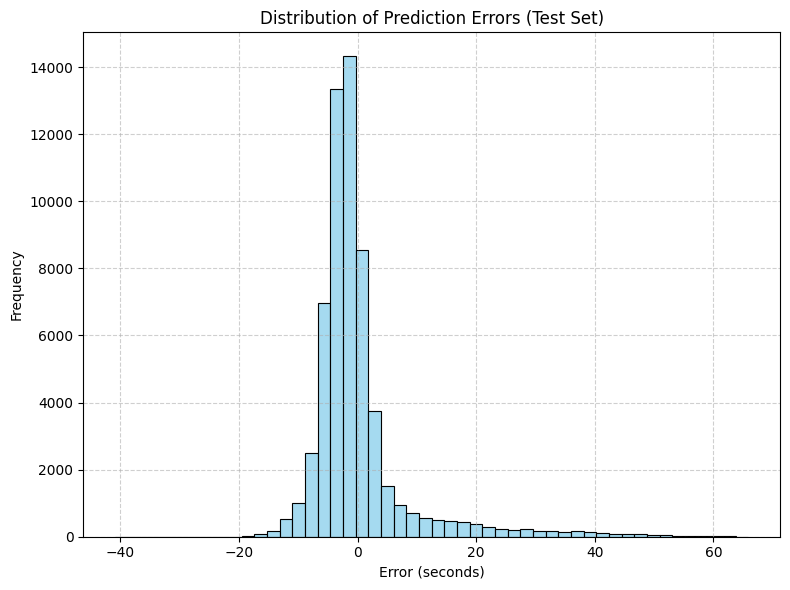

In [8]:
# Calculate errors from the predictions of the last OLS model (bc2a5227)
errors = y_test - y_pred_test

plt.figure(figsize=(8, 6))
sns.histplot(errors, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Prediction Errors (Test Set)')
plt.xlabel('Error (seconds)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The model did not improve under L2 regularization. We will need to think of other methods to make this model better.

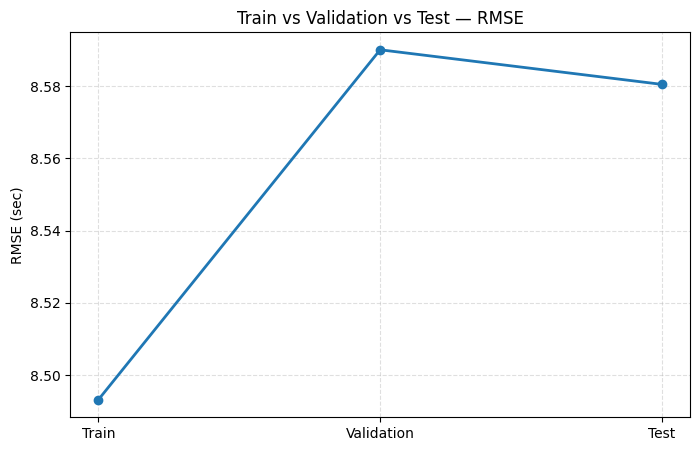

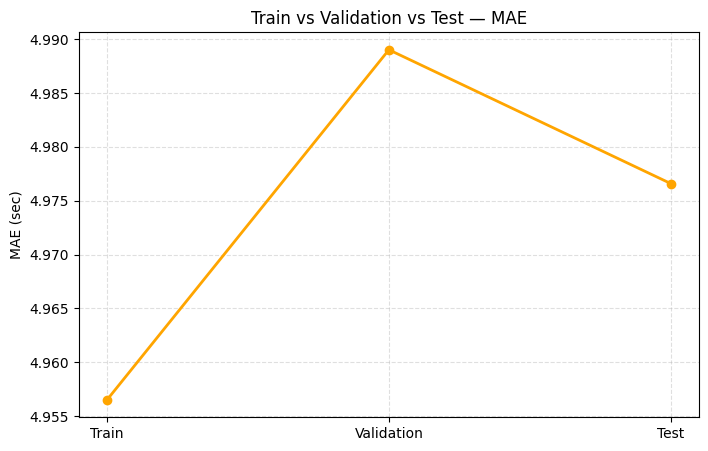

RMSE: 8.493165602746119 8.590008592883137 8.580431861890359
MAE : 4.956510274904621 4.989024723657933 4.976598801969276


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# ---- Compute metrics from existing variables ----
train_rmse = np.sqrt(mean_squared_error(y_tr, y_tr_hat))
val_rmse   = np.sqrt(mean_squared_error(y_va, y_va_hat))
test_rmse  = np.sqrt(mean_squared_error(y_te, y_te_hat))

train_mae = mean_absolute_error(y_tr, y_tr_hat)
val_mae   = mean_absolute_error(y_va, y_va_hat)
test_mae  = mean_absolute_error(y_te, y_te_hat)

# ---- Plot RMSE ----
plt.figure(figsize=(8,5))
plt.plot(["Train","Validation","Test"],
         [train_rmse, val_rmse, test_rmse],
         marker='o', linewidth=2)
plt.title("Train vs Validation vs Test — RMSE")
plt.ylabel("RMSE (sec)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# ---- Plot MAE ----
plt.figure(figsize=(8,5))
plt.plot(["Train","Validation","Test"],
         [train_mae, val_mae, test_mae],
         marker='o', linewidth=2, color='orange')
plt.title("Train vs Validation vs Test — MAE")
plt.ylabel("MAE (sec)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("RMSE:", train_rmse, val_rmse, test_rmse)
print("MAE :", train_mae, val_mae, test_mae)


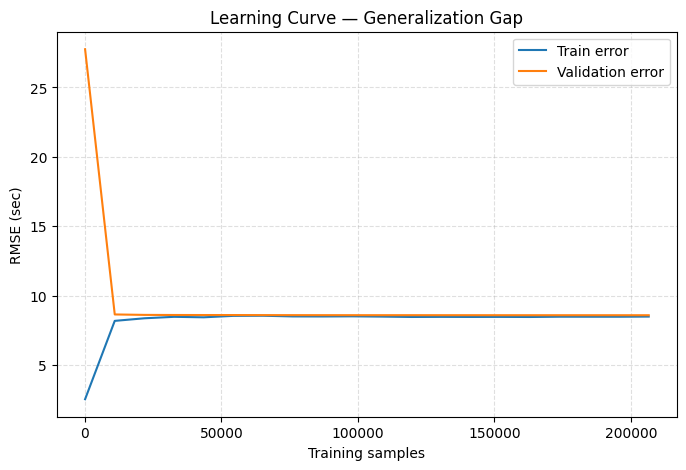

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# We will use a simple model you already trained — for example OLS
# But we retrain it on progressively larger subsets of X_tr, y_tr.

from sklearn.linear_model import LinearRegression
# (you can change to Ridge(), SGDRegressor(), etc.)

train_errors = []
val_errors = []
sizes = np.linspace(100, len(X_tr), 20, dtype=int)  # 20 points from 100 → full training size

for m in sizes:
    # subset first m samples
    X_sub = X_tr[:m]
    y_sub = y_tr[:m]

    # train model
    model = LinearRegression()
    model.fit(X_sub, y_sub)

    # predict on train subset
    y_sub_hat = model.predict(X_sub)
    train_rmse = np.sqrt(mean_squared_error(y_sub, y_sub_hat))

    # predict on validation set
    y_val_hat = model.predict(X_va)
    val_rmse = np.sqrt(mean_squared_error(y_va, y_val_hat))

    train_errors.append(train_rmse)
    val_errors.append(val_rmse)

# ----- Plot -----
plt.figure(figsize=(8,5))
plt.plot(sizes, train_errors, label="Train error")
plt.plot(sizes, val_errors, label="Validation error")
plt.xlabel("Training samples")
plt.ylabel("RMSE (sec)")
plt.title("Learning Curve — Generalization Gap")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


Model is stable, starts doing very well at even 100000 samples
Add nonlinear features:

LapsSincePitCubed  Tire degradation is strongly convex

FuelLoadProxySquared   Heavy fuel makes early-stint tire wear worse, which is nonlinear

Fuel_Tire_Interaction   Heavy fuel makes early-stint tire wear worse, which is nonlinear

LapNumberSquared   Track evolution, ambient temperature, and fuel load interact over time


IsOutLap  This captures the nonlinear drop in grip right after new tires are fitted.

-------------------------------------------------------------------------------------

-----------------------------------------------------

----------------------------------------------------------------

-----------------------------------------------------------------------------

In [12]:
import os
import numpy as np
import pandas as pd

# --------------------------------------------------
# 0) Helper: load CSVs from the current folder
# --------------------------------------------------
DATA_DIR = os.getcwd()
print("DATA_DIR =", DATA_DIR)
print("Files here:", os.listdir(DATA_DIR))

def load_csv(filename: str) -> pd.DataFrame:
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {filename} at {path}")
    print(f"✓ Loaded {filename} from {path}")
    return pd.read_csv(path, low_memory=False)

# --------------------------------------------------
# 1) Load lap times and initial features to recreate 'df'
# --------------------------------------------------
lap_times = load_csv("lap_times.csv")
lap_times["LapTime_sec"] = (
    pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
)
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()
lap_times["LapTime_sec"] = lap_times["LapTime_sec"].astype(float)

fuel     = load_csv("features_fuel_load_proxy.csv")
laps_pit = load_csv("features_laps_before_pit.csv")
num_pit  = load_csv("features_num_pitstops.csv")
prev_st  = load_csv("features_prev_race_standing.csv")
races    = load_csv("races.csv")
races    = races[races["year"] >= 2010].copy()  # Filter as in previous step

results        = load_csv("results.csv")[["raceId","driverId","constructorId"]].drop_duplicates()
pit_stops_orig = load_csv("pit_stops.csv")  # Original pit stops for LapsSincePit

# Apply the 1–4 pit stop filter before using pit_stops_orig for LapsSincePit calculation
pit_stops_for_laps_since_pit = pit_stops_orig[pit_stops_orig["stop"].between(1, 4)].copy()

# Average laps-before-pit per race-driver
laps_avg = (
    laps_pit
    .groupby(["raceId","driverId"], as_index=False)["LapsBeforePit"]
    .mean()
    .rename(columns={"LapsBeforePit": "AvgLapsBeforePit"})
)

# --------------------------------------------------
# 2) Merge everything to create the base df
# --------------------------------------------------
df = (
    lap_times[["raceId","driverId","lap","LapTime_sec"]]
    .merge(
        fuel[["raceId","driverId","lap","FuelLoadProxy"]],
        on=["raceId","driverId","lap"],
        how="left",
    )
    .merge(num_pit,  on=["raceId","driverId"], how="left")
    .merge(laps_avg, on=["raceId","driverId"], how="left")
    .merge(prev_st,  on=["raceId","driverId"], how="left")
    .merge(races[["raceId","circuitId","year"]], on="raceId", how="left")
    .merge(results, on=["raceId","driverId"], how="left")
)

# --------------------------------------------------
# 3) Clean + filter outliers (as in previous step)
# --------------------------------------------------
df = df.dropna(subset=[
    "LapTime_sec","FuelLoadProxy","NumPitStops",
    "AvgLapsBeforePit","PrevRaceStanding",
    "circuitId","driverId","constructorId"
])

df = df[df["LapTime_sec"] < 200]
df = df[df["LapTime_sec"] > 60]

df = df.groupby("raceId", group_keys=False).apply(
    lambda g: g[g["LapTime_sec"] < 1.5 * g["LapTime_sec"].median()]
)

# --------------------------------------------------
# 4) Create LapsSincePit and LapsSincePitSquared
# --------------------------------------------------
pit_laps = (
    pit_stops_for_laps_since_pit.groupby(["raceId", "driverId"])[["lap"]]
    .apply(lambda x: sorted(x["lap"].unique().tolist()))
    .to_dict()
)

def laps_since_last_pit(row):
    pits = pit_laps.get((row["raceId"], row["driverId"]), [])
    pits_before = [p for p in pits if p < row["lap"]]
    return row["lap"] - max(pits_before) if pits_before else row["lap"]

df["LapsSincePit"] = df.apply(laps_since_last_pit, axis=1)
df["LapsSincePitSquared"] = df["LapsSincePit"] ** 2

# --------------------------------------------------
# 5) PitStopDuration_sec feature
# --------------------------------------------------
pit_stops_df = pit_stops_orig.copy()

# keep only stops 1–4
pit_stops_df = pit_stops_df[pit_stops_df["stop"].between(1, 4)].copy()

# main duration column
pit_stops_df["PitStopDuration_sec"] = pd.to_numeric(
    pit_stops_df["duration"], errors="coerce"
)

# fallback to milliseconds if needed
missing_duration_mask = pit_stops_df["PitStopDuration_sec"].isna()
pit_stops_df.loc[missing_duration_mask, "PitStopDuration_sec"] = (
    pd.to_numeric(
        pit_stops_df.loc[missing_duration_mask, "milliseconds"],
        errors="coerce"
    ) / 1000.0
)

# drop rows still missing duration
pit_stops_df = pit_stops_df.dropna(subset=["PitStopDuration_sec"])

pit_duration_feature = pit_stops_df[["raceId","driverId","lap","PitStopDuration_sec"]].copy()

# merge into df
df = pd.merge(df, pit_duration_feature,
              on=["raceId","driverId","lap"], how="left")

# non-pit laps → 0 duration
df["PitStopDuration_sec"] = df["PitStopDuration_sec"].fillna(0)

print("\n--- 'df' DataFrame created successfully ---")
print(df.head())
print(df.shape)


DATA_DIR = c:\Users\User\Desktop\AUB\MECH\MECH 535\Project
Files here: ['.venv', 'both.ipynb', 'circuits.csv', 'constructors.csv', 'constructor_results.csv', 'constructor_standings.csv', 'Copy_of_LapTime (1).ipynb', 'drivers.csv', 'driver_standings.csv', 'F1_LapTime_DeepLearning_Report.docx', 'features_fuel_load_proxy.csv', 'features_laps_before_pit.csv', 'features_num_pitstops.csv', 'features_prev_race_standing.csv', 'figs', 'Forest.html', 'Forest.ipynb', 'Given the nonlinearities of our system.docx', 'Kaggledataset.html', 'Kaggledataset.ipynb', 'lapnet_best.pt', 'lap_times.csv', 'NeuralNetwork.html', 'NeuralNetwork.ipynb', 'NN_Absolute.ipynb', 'NN_delta.ipynb', 'pit_stops.csv', 'qualifying.csv', 'races.csv', 'Random Forest.docx', 'results.csv', 'seasons.csv', 'sprint_results.csv', 'status.csv', 'Untitled-1.ipynb', '~$ven the nonlinearities of our system.docx', '~$_LapTime_DeepLearning_Report.docx']
✓ Loaded lap_times.csv from c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\lap_times.

C:\Users\User\AppData\Local\Temp\ipykernel_26120\666568989.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("raceId", group_keys=False).apply(



--- 'df' DataFrame created successfully ---
   raceId  driverId  lap  LapTime_sec  FuelLoadProxy  NumPitStops  \
0     842        20    1      109.614       0.982143          3.0   
1     842        20    2      104.539       0.964286          3.0   
2     842        20    3      104.209       0.946429          3.0   
3     842        20    4      104.369       0.928571          3.0   
4     842        20    5      104.378       0.910714          3.0   

   AvgLapsBeforePit  PrevRaceStanding  circuitId    year  constructorId  \
0         13.333333               1.0        2.0  2011.0              9   
1         13.333333               1.0        2.0  2011.0              9   
2         13.333333               1.0        2.0  2011.0              9   
3         13.333333               1.0        2.0  2011.0              9   
4         13.333333               1.0        2.0  2011.0              9   

   LapsSincePit  LapsSincePitSquared  PitStopDuration_sec  
0           1.0              

✓ Found lap_times.csv → c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\lap_times.csv
✓ Found features_fuel_load_proxy.csv → c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\features_fuel_load_proxy.csv
✓ Found features_laps_before_pit.csv → c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\features_laps_before_pit.csv
✓ Found features_num_pitstops.csv → c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\features_num_pitstops.csv
✓ Found features_prev_race_standing.csv → c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\features_prev_race_standing.csv
✓ Found races.csv → c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\races.csv
✓ Found results.csv → c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\results.csv
✓ Found pit_stops.csv → c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\pit_stops.csv
After cleaning: (295038, 11)
Added nonlinear features to df_nonlinear.
Shapes → Train: (206518, 141), Val: (44264, 141), Test: (44256, 141)

=== NONLINEAR OLS MODEL PERFORMANCE ===
Train     R²=0.7288   M

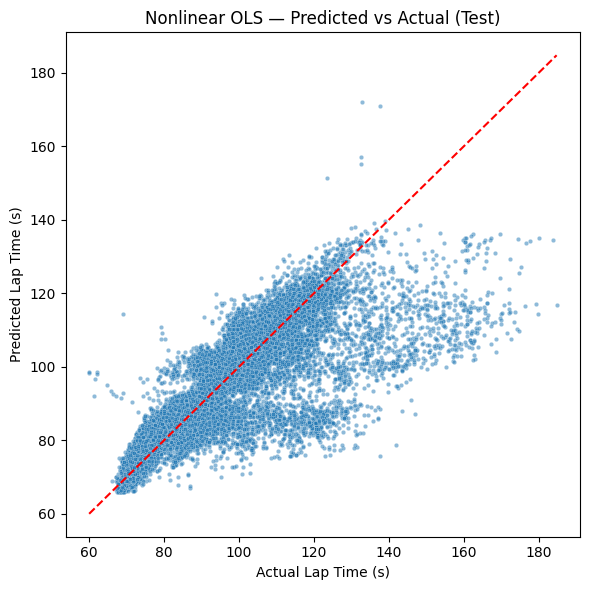

In [14]:
# ============================================================
#   NONLINEAR OLS MODEL — Lap Time Prediction
#   (Fuel, Tire, Track Evolution, Pit Duration, IDs)
# ============================================================

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm

# ------------------------------------------------------------
# 0) Helper functions: robust CSV loader (Colab + local)
# ------------------------------------------------------------
def find_csv(start_root, filename):
    target = filename.lower()
    for cur, _, files in os.walk(start_root):
        for f in files:
            if f.lower() == target:
                return os.path.join(cur, f)
    return None

def load_csv_anywhere(filename):
    # Try current working dir + common Colab locations
    roots = [
        os.getcwd(),
        "/content",
        "/content/Project",
        "/content/drive/MyDrive",
    ]
    seen = set()
    for root in roots:
        if root in seen or not os.path.isdir(root):
            continue
        seen.add(root)
        p = find_csv(root, filename)
        if p:
            print(f"✓ Found {filename} → {p}")
            return pd.read_csv(p, low_memory=False)
    raise FileNotFoundError(f"Could not find {filename}")

# ------------------------------------------------------------
# 1) Recreate base df with all linear features
# ------------------------------------------------------------
lap_times = load_csv_anywhere("lap_times.csv")
lap_times["LapTime_sec"] = (
    pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
)
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()
lap_times["LapTime_sec"] = lap_times["LapTime_sec"].astype(float)

fuel      = load_csv_anywhere("features_fuel_load_proxy.csv")
laps_pit  = load_csv_anywhere("features_laps_before_pit.csv")
num_pit   = load_csv_anywhere("features_num_pitstops.csv")
prev_st   = load_csv_anywhere("features_prev_race_standing.csv")
races     = load_csv_anywhere("races.csv")
races     = races[races["year"] >= 2010].copy()  # modern era only

results   = load_csv_anywhere("results.csv")[["raceId","driverId","constructorId"]].drop_duplicates()
pit_stops_orig = load_csv_anywhere("pit_stops.csv")

# Filter pit stops 1–4 for laps-since-pit logic
pit_stops_for_laps_since_pit = pit_stops_orig[
    pit_stops_orig["stop"].between(1, 4)
].copy()

# Avg laps-before-pit per race/driver
laps_avg = (
    laps_pit
    .groupby(["raceId","driverId"], as_index=False)["LapsBeforePit"]
    .mean()
    .rename(columns={"LapsBeforePit":"AvgLapsBeforePit"})
)

# Merge everything to create base df
df = (
    lap_times[["raceId","driverId","lap","LapTime_sec"]]
    .merge(
        fuel[["raceId","driverId","lap","FuelLoadProxy"]],
        on=["raceId","driverId","lap"], how="left"
    )
    .merge(num_pit,  on=["raceId","driverId"], how="left")
    .merge(laps_avg, on=["raceId","driverId"], how="left")
    .merge(prev_st,  on=["raceId","driverId"], how="left")
    .merge(races[["raceId","circuitId","year"]], on="raceId", how="left")
    .merge(results, on=["raceId","driverId"], how="left")
)

# ------------------------------------------------------------
# 2) Clean + filter outliers (safe: raceId stays a column)
# ------------------------------------------------------------
df = df.dropna(subset=[
    "LapTime_sec","FuelLoadProxy","NumPitStops",
    "AvgLapsBeforePit","PrevRaceStanding",
    "circuitId","driverId","constructorId"
])

# very long / very short laps
df = df[(df["LapTime_sec"] < 200) & (df["LapTime_sec"] > 60)]

# remove laps > 1.5× median for that race (vectorised)
median_per_race = df.groupby("raceId")["LapTime_sec"].transform("median")
df = df[df["LapTime_sec"] < 1.5 * median_per_race].copy()

print("After cleaning:", df.shape)

# ------------------------------------------------------------
# 3) LapsSincePit, LapsSincePitSquared
# ------------------------------------------------------------
pit_laps = (
    pit_stops_for_laps_since_pit
    .groupby(["raceId","driverId"])["lap"]
    .apply(lambda x: sorted(x.unique().tolist()))
    .to_dict()
)

def laps_since_last_pit(row):
    pits = pit_laps.get((row["raceId"], row["driverId"]), [])
    pits_before = [p for p in pits if p < row["lap"]]
    return row["lap"] - max(pits_before) if pits_before else row["lap"]

df["LapsSincePit"] = df.apply(laps_since_last_pit, axis=1)
df["LapsSincePitSquared"] = df["LapsSincePit"] ** 2

# ------------------------------------------------------------
# 4) PitStopDuration_sec feature
# ------------------------------------------------------------
pit_stops_df = pit_stops_orig.copy()
pit_stops_df = pit_stops_df[pit_stops_df["stop"].between(1,4)].copy()

pit_stops_df["PitStopDuration_sec"] = pd.to_numeric(
    pit_stops_df["duration"], errors="coerce"
)
missing = pit_stops_df["PitStopDuration_sec"].isna()
pit_stops_df.loc[missing, "PitStopDuration_sec"] = (
    pd.to_numeric(
        pit_stops_df.loc[missing, "milliseconds"], errors="coerce"
    ) / 1000.0
)
pit_stops_df = pit_stops_df.dropna(subset=["PitStopDuration_sec"])

pit_duration_feature = pit_stops_df[
    ["raceId","driverId","lap","PitStopDuration_sec"]
].copy()

df = pd.merge(
    df, pit_duration_feature,
    on=["raceId","driverId","lap"], how="left"
)
df["PitStopDuration_sec"] = df["PitStopDuration_sec"].fillna(0)

# ------------------------------------------------------------
# 5) Build df_nonlinear with extra nonlinear features
# ------------------------------------------------------------
df_nonlinear = df.copy()

# Tire wear nonlinearity
df_nonlinear["LapsSincePitSquared"] = df_nonlinear["LapsSincePit"] ** 2
df_nonlinear["LapsSincePitCubed"]   = df_nonlinear["LapsSincePit"] ** 3

# Fuel load nonlinearity
df_nonlinear["FuelLoadProxySquared"] = df_nonlinear["FuelLoadProxy"] ** 2

# Fuel × Tire interaction
df_nonlinear["Fuel_Tire_Interaction"] = (
    df_nonlinear["FuelLoadProxy"] * df_nonlinear["LapsSincePit"]
)

# Track evolution nonlinearity
df_nonlinear["LapNumberSquared"] = df_nonlinear["lap"] ** 2
df_nonlinear["LapNumberCubed"]   = df_nonlinear["lap"] ** 3

# Out-lap indicator
df_nonlinear["IsOutLap"] = (df_nonlinear["LapsSincePit"] == 1).astype(int)

print("Added nonlinear features to df_nonlinear.")

# ------------------------------------------------------------
# 6) One-hot encode categorical IDs
# ------------------------------------------------------------
for col in ["circuitId","driverId","constructorId"]:
    df_nonlinear[col] = df_nonlinear[col].astype(str)

df_encoded_nl = pd.get_dummies(
    df_nonlinear,
    columns=["circuitId","driverId","constructorId"],
    drop_first=True
)

# ------------------------------------------------------------
# 7) Define feature matrix and target
# ------------------------------------------------------------
base_features_nl = [
    "NumPitStops",
    "AvgLapsBeforePit",
    "PrevRaceStanding",
    "FuelLoadProxy",
    "LapsSincePit",
    "LapsSincePitSquared",
    "LapsSincePitCubed",
    "FuelLoadProxySquared",
    "Fuel_Tire_Interaction",
    "LapNumberSquared",
    "LapNumberCubed",
    "IsOutLap",
    "PitStopDuration_sec",
]

cat_features_nl = [
    c for c in df_encoded_nl.columns
    if c.startswith(("circuitId_","driverId_","constructorId_"))
]

features_nl = base_features_nl + cat_features_nl

X_nl = df_encoded_nl[features_nl]
y_nl = df_encoded_nl["LapTime_sec"]

mask = X_nl.notna().all(axis=1) & y_nl.notna()
X_nl = X_nl.loc[mask].astype(float)
y_nl = y_nl.loc[mask].astype(float)

# ------------------------------------------------------------
# 8) 70/15/15 split
# ------------------------------------------------------------
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_nl, y_nl, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42
)

print(f"Shapes → Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ------------------------------------------------------------
# 9) Fit OLS regression (statsmodels)
# ------------------------------------------------------------
X_train_const = sm.add_constant(X_train)
X_val_const   = sm.add_constant(X_val,   has_constant="add")
X_test_const  = sm.add_constant(X_test,  has_constant="add")

ols_nl = sm.OLS(y_train, X_train_const).fit()

# ------------------------------------------------------------
# 10) Evaluate model
# ------------------------------------------------------------
def eval_metrics(label, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{label:8}  R²={r2:.4f}   MAE={mae:.3f}s   RMSE={rmse:.3f}s")
    return rmse

print("\n=== NONLINEAR OLS MODEL PERFORMANCE ===")
y_train_hat = ols_nl.predict(X_train_const)
y_val_hat   = ols_nl.predict(X_val_const)
y_test_hat  = ols_nl.predict(X_test_const)

eval_metrics("Train", y_train, y_train_hat)
eval_metrics("Val",   y_val,   y_val_hat)
eval_metrics("Test",  y_test,  y_test_hat)

# ------------------------------------------------------------
# 11) Plot predicted vs actual (Test)
# ------------------------------------------------------------
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_test_hat, s=10, alpha=0.5)
lo = float(min(y_test.min(), y_test_hat.min()))
hi = float(max(y_test.max(), y_test_hat.max()))
plt.plot([lo, hi], [lo, hi], 'r--')
plt.xlabel("Actual Lap Time (s)")
plt.ylabel("Predicted Lap Time (s)")
plt.title("Nonlinear OLS — Predicted vs Actual (Test)")
plt.tight_layout()
plt.show()


-------------------------------------------------------------------

Train: (206518, 141), Val: (44264, 141)


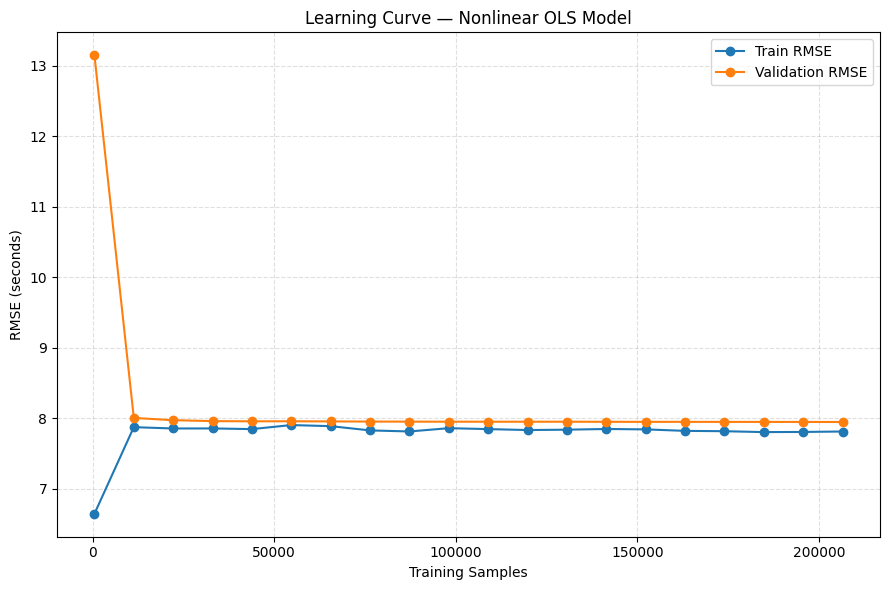

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# --------------------------------------------------
# 1) Make sure we have train/val split
# --------------------------------------------------
try:
    X_train, X_val, y_train, y_val
except NameError:
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_nl, y_nl, test_size=0.15, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.1765, random_state=42
    )

print(f"Train: {X_train.shape}, Val: {X_val.shape}")

# --------------------------------------------------
# 2) Build learning curve
# --------------------------------------------------
train_errors = []
val_errors   = []

# 20 points from 500 samples up to full train size
sample_sizes = np.linspace(500, len(X_train), 20, dtype=int)

for m in sample_sizes:
    # subset first m samples
    X_sub = X_train.iloc[:m]
    y_sub = y_train.iloc[:m]

    # add constant
    X_sub_const = sm.add_constant(X_sub, has_constant="add")

    # fit OLS on subset
    model_sub = sm.OLS(y_sub, X_sub_const).fit()

    # train RMSE
    y_sub_hat = model_sub.predict(X_sub_const)
    train_rmse = np.sqrt(mean_squared_error(y_sub, y_sub_hat))

    # validation RMSE (full val set)
    X_val_const = sm.add_constant(X_val, has_constant="add")
    y_val_hat = model_sub.predict(X_val_const)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_hat))

    train_errors.append(train_rmse)
    val_errors.append(val_rmse)

# --------------------------------------------------
# 3) Plot learning curve
# --------------------------------------------------
plt.figure(figsize=(9, 6))
plt.plot(sample_sizes, train_errors, label="Train RMSE", marker="o")
plt.plot(sample_sizes, val_errors,   label="Validation RMSE", marker="o")
plt.xlabel("Training Samples")
plt.ylabel("RMSE (seconds)")
plt.title("Learning Curve — Nonlinear OLS Model")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


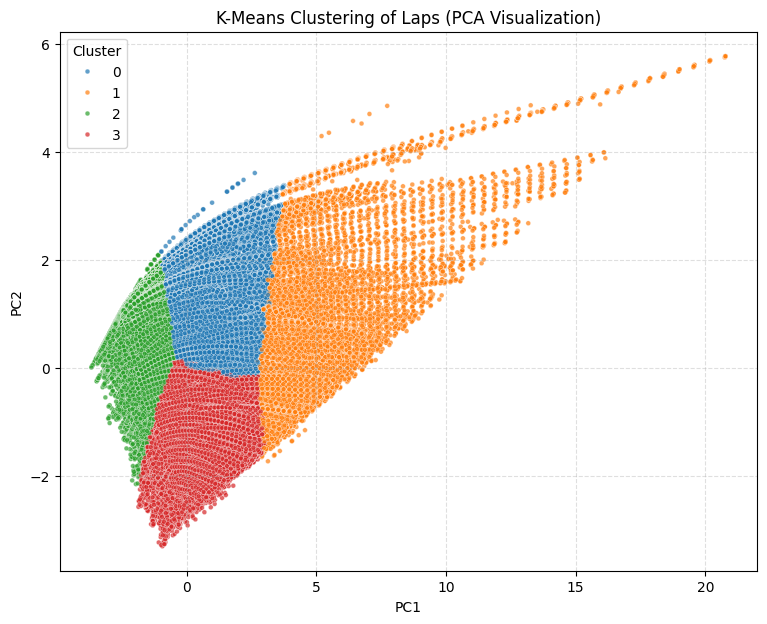


Cluster Summary (Means of Features):
         LapTime_sec  FuelLoadProxy  LapsSincePit  LapsSincePitSquared  \
Cluster                                                                  
0          88.806381       0.594133     20.287614           441.623960   
1          85.947168       0.161800     38.963903          1576.988121   
2          99.527568       0.810081      6.109884            49.721964   
3          94.294947       0.274136     12.380472           206.048261   

         LapsSincePitCubed  FuelLoadProxySquared  Fuel_Tire_Interaction  
Cluster                                                                  
0             10267.179443              0.372078              11.600193  
1             66775.969900              0.043729               6.258683  
2               466.184319              0.670780               4.834053  
3              4017.275440              0.099577               2.827162  


In [16]:
# ===============================================================
# K-MEANS CLUSTERING OF LAPS INTO STINT PHASES + PCA VISUALIZATION
# ===============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------
# 1. Select meaningful features for stint-phase clustering
# ---------------------------------------------------------------
# These must already exist in df_nonlinear (created earlier)
cluster_features = [
    "LapTime_sec",
    "FuelLoadProxy",
    "LapsSincePit",
    "LapsSincePitSquared",
    "LapsSincePitCubed",
    "FuelLoadProxySquared",
    "Fuel_Tire_Interaction"
]

# Extract subset
Xc = df_nonlinear[cluster_features].dropna()

# ---------------------------------------------------------------
# 2. Scale the data
# ---------------------------------------------------------------
scaler = StandardScaler()
Xc_scaled = scaler.fit_transform(Xc)

# ---------------------------------------------------------------
# 3. Run K-Means with K = 4 (typical: early, mid, late, pit)
# ---------------------------------------------------------------
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(Xc_scaled)

# Attach cluster to a new visualization dataframe
df_vis = df_nonlinear.loc[Xc.index].copy()
df_vis["Cluster"] = cluster_labels

# ---------------------------------------------------------------
# 4. PCA for Visualization (reduce to 2D)
# ---------------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(Xc_scaled)

df_vis["PC1"] = X_pca[:, 0]
df_vis["PC2"] = X_pca[:, 1]

# ---------------------------------------------------------------
# 5. Plot the Clusters in PCA Space
# ---------------------------------------------------------------
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df_vis, x="PC1", y="PC2",
    hue="Cluster", palette="tab10",
    s=12, alpha=0.7
)
plt.title("K-Means Clustering of Laps (PCA Visualization)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Cluster")
plt.show()

# ---------------------------------------------------------------
# 6. Inspect Cluster Means (for interpretation)
# ---------------------------------------------------------------
cluster_summary = df_vis.groupby("Cluster")[cluster_features].mean()
print("\nCluster Summary (Means of Features):")
print(cluster_summary)

In K means, we can see that the whole data falls into almost 1 cluster. Kmeans cannot cluster the data

✓ Found circuits.csv → .\circuits.csv
Strategy sim → Monza, raceId=1038, driverId=840, laps=53

=== Strategy Summary (Monza) ===
1-stop | Pits at laps [26] | Total time = 4148.1 s
2-stop | Pits at laps [17, 35] | Total time = 4360.3 s
3-stop | Pits at laps [13, 26, 39] | Total time = 4451.6 s


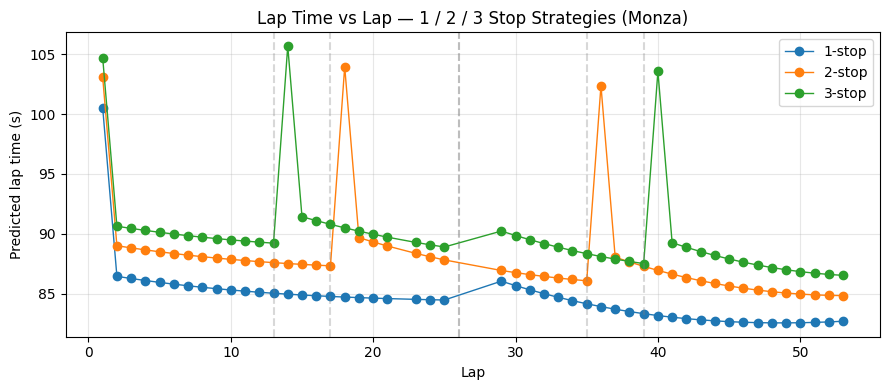

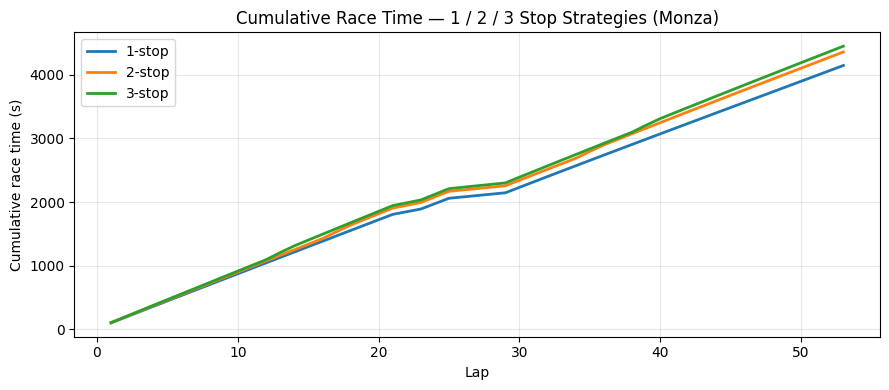

In [30]:
# ==========================================================
# Race Strategy Simulation using model_sub
# Compare 1-stop, 2-stop, 3-stop strategies at Monza
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ----------------------------------------------------------
# 0. Helpers to find circuits.csv (for Monza mapping)
# ----------------------------------------------------------
def find_csv(start_root, filename):
    target = filename.lower()
    for cur, _, files in os.walk(start_root):
        for f in files:
            if f.lower() == target:
                return os.path.join(cur, f)
    return None

def load_csv_anywhere(filename):
    # adjust roots if your data lives elsewhere
    for root in (".", ".."):
        if os.path.isdir(root):
            p = find_csv(root, filename)
            if p:
                print(f"✓ Found {filename} → {p}")
                return pd.read_csv(p, low_memory=False)
    raise FileNotFoundError(f"Could not find {filename} in current/parent folders")


# ----------------------------------------------------------
# 1. Choose Monza race + driver
# ----------------------------------------------------------
def get_monza_slice(df):
    """
    Return rows of df corresponding to Monza.
    Tries:
      1) df['circuitRef'] == 'monza'
      2) df['name'] contains 'Monza'
      3) df['circuitId'] mapped via circuits.csv
    """
    # Case 1: circuitRef directly in df
    if "circuitRef" in df.columns:
        tmp = df[df["circuitRef"].astype(str).str.lower() == "monza"].copy()
        if not tmp.empty:
            return tmp

    # Case 2: name column in df
    if "name" in df.columns:
        tmp = df[df["name"].astype(str).str.contains("monza", case=False, na=False)].copy()
        if not tmp.empty:
            return tmp

    # Case 3: use circuitId + circuits.csv
    if "circuitId" in df.columns:
        circuits = load_csv_anywhere("circuits.csv")
        # match either circuitRef == 'monza' OR name contains 'Monza'
        mask_monza = (
            circuits.get("circuitRef", pd.Series("", index=circuits.index))
                    .astype(str).str.lower().eq("monza")
        ) | (
            circuits.get("name", pd.Series("", index=circuits.index))
                    .astype(str).str.contains("monza", case=False, na=False)
        )
        monza_ids = circuits.loc[mask_monza, "circuitId"].unique()
        if len(monza_ids) == 0:
            raise ValueError("circuits.csv found but no Monza circuitId detected.")

        tmp = df[df["circuitId"].isin(monza_ids)].copy()
        if not tmp.empty:
            return tmp

    raise ValueError(
        "Cannot find Monza rows: df has no usable ['circuitRef', 'name', 'circuitId→circuits.csv'] mapping."
    )


monza_df = get_monza_slice(df)
if monza_df.empty:
    raise ValueError("No Monza rows in df after filtering.")

# pick a random Monza race
race_id = monza_df["raceId"].sample(1, random_state=10).iloc[0]
race_df_base = monza_df[monza_df["raceId"] == race_id].copy()

# pick a random driver in that Monza race
driver_id = race_df_base["driverId"].sample(1, random_state=11).iloc[0]
race_df_base = race_df_base[race_df_base["driverId"] == driver_id].copy()
race_df_base = race_df_base.sort_values("lap").reset_index(drop=True)

total_laps = int(race_df_base["lap"].max())
print(f"Strategy sim → Monza, raceId={race_id}, driverId={driver_id}, laps={total_laps}")

pit_loss_sec = 22.0  # assumed fixed time loss per pit stop at Monza


# ----------------------------------------------------------
# 2. Build nonlinear features for a given pit plan
# ----------------------------------------------------------
def build_features_for_strategy(base_df, pit_plan):
    """
    base_df : rows for one race+driver (sorted by lap)
    pit_plan: list of pit-stop lap numbers (e.g., [17, 34])
    returns: (sim_df, X_sim_aligned)
    """
    sim_df = base_df.copy()

    # strategy summary features
    sim_df["NumPitStops"] = len(pit_plan)
    sim_df["AvgLapsBeforePit"] = total_laps / len(pit_plan) if pit_plan else total_laps

    # LapsSincePit based on hypothetical plan
    def laps_since_pit_from_plan(row):
        lap = row["lap"]
        pits_before = [p for p in pit_plan if p < lap]
        return lap - max(pits_before) if pits_before else lap

    sim_df["LapsSincePit"] = sim_df.apply(laps_since_pit_from_plan, axis=1)

    # Nonlinear engineered features (same logic as training)
    sim_df["LapsSincePitSquared"]   = sim_df["LapsSincePit"] ** 2
    sim_df["LapsSincePitCubed"]     = sim_df["LapsSincePit"] ** 3
    sim_df["FuelLoadProxySquared"]  = sim_df["FuelLoadProxy"] ** 2
    sim_df["Fuel_Tire_Interaction"] = sim_df["FuelLoadProxy"] * sim_df["LapsSincePit"]
    sim_df["LapNumberSquared"]      = sim_df["lap"] ** 2
    sim_df["LapNumberCubed"]        = sim_df["lap"] ** 3
    sim_df["IsOutLap"]              = (sim_df["LapsSincePit"] == 1).astype(int)

    # one-hot encode IDs (must match model_sub training)
    sim_df["circuitId"]     = sim_df["circuitId"].astype(str)
    sim_df["driverId"]      = sim_df["driverId"].astype(str)
    sim_df["constructorId"] = sim_df["constructorId"].astype(str)

    sim_encoded = pd.get_dummies(
        sim_df,
        columns=["circuitId", "driverId", "constructorId"],
        drop_first=True
    )

    # align with model_sub exog
    expected_cols = list(model_sub.model.exog_names)

    if "const" in expected_cols and "const" not in sim_encoded.columns:
        sim_encoded["const"] = 1.0

    X_sim = sim_encoded.reindex(columns=expected_cols, fill_value=0)

    return sim_df, X_sim


# ----------------------------------------------------------
# 3. Simulate race for a given strategy
# ----------------------------------------------------------
def simulate_strategy(name, pit_plan):
    """
    name    : '1-stop', '2-stop', ...
    pit_plan: list of pit-stop lap numbers
    returns : dict with lap_times, cum_times, total_time, etc.
    """
    sim_df, X_sim = build_features_for_strategy(race_df_base, pit_plan)

    pred_lap_times = model_sub.predict(X_sim).values  # seconds per lap

    cum_times = []
    total_time = 0.0

    for lap_num, lap_time in zip(sim_df["lap"].values, pred_lap_times):
        total_time += lap_time
        if lap_num in pit_plan:
            total_time += pit_loss_sec
        cum_times.append(total_time)

    return {
        "name": name,
        "pit_plan": pit_plan,
        "lap": sim_df["lap"].values,
        "lap_times": pred_lap_times,
        "cum_times": np.array(cum_times),
        "total_time": total_time
    }


# ----------------------------------------------------------
# 4. Define 1-, 2-, 3-stop strategies (evenly spaced)
# ----------------------------------------------------------
one_stop_lap    = int(total_laps * 0.50)
two_stop_laps   = [int(total_laps * 1/3), int(total_laps * 2/3)]
three_stop_laps = [int(total_laps * 1/4),
                   int(total_laps * 2/4),
                   int(total_laps * 3/4)]

strategies = [
    simulate_strategy("1-stop", [one_stop_lap]),
    simulate_strategy("2-stop", two_stop_laps),
    simulate_strategy("3-stop", three_stop_laps),
]


# ----------------------------------------------------------
# 5. Print summary table
# ----------------------------------------------------------
print("\n=== Strategy Summary (Monza) ===")
for s in strategies:
    print(f"{s['name']:6s} | Pits at laps {s['pit_plan']} | "
          f"Total time = {s['total_time']:.1f} s")


# ----------------------------------------------------------
# 6. Plot lap times vs lap for each strategy
# ----------------------------------------------------------
plt.figure(figsize=(9, 4))
for s in strategies:
    plt.plot(s["lap"], s["lap_times"], marker="o", linewidth=1, label=s["name"])
    for p in s["pit_plan"]:
        plt.axvline(p, color="gray", linestyle="--", alpha=0.3)

plt.xlabel("Lap")
plt.ylabel("Predicted lap time (s)")
plt.title("Lap Time vs Lap — 1 / 2 / 3 Stop Strategies (Monza)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 7. Plot cumulative race time for each strategy
# ----------------------------------------------------------
plt.figure(figsize=(9, 4))
for s in strategies:
    plt.plot(s["lap"], s["cum_times"], linewidth=2, label=f"{s['name']}")

plt.xlabel("Lap")
plt.ylabel("Cumulative race time (s)")
plt.title("Cumulative Race Time — 1 / 2 / 3 Stop Strategies (Monza)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [33]:
coef_series = pd.Series(linreg.coef_, index=features)

# Sort by absolute value to see strongest effects first (optional)
coef_series = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index)

print(coef_series.to_string())

circuitId_15         28.312886
circuitId_13         26.551584
circuitId_73         25.037763
circuitId_35         19.407845
circuitId_2          19.347146
circuitId_69         18.809883
circuitId_12         18.484774
circuitId_71         17.600383
circuitId_24         16.849817
circuitId_17         16.153189
circuitId_34         15.340105
circuitId_80         14.870271
circuitId_22         14.198043
circuitId_70        -12.806838
circuitId_77         12.060270
circuitId_5          11.981729
circuitId_3          11.943199
circuitId_79         11.276168
circuitId_9          11.118292
circuitId_20         10.916684
FuelLoadProxy        -7.313382
constructorId_166     6.877096
circuitId_39         -6.119475
circuitId_18         -5.893934
driverId_861         -5.157468
constructorId_206     5.147222
driverId_860          4.915393
constructorId_164     4.761973
circuitId_68          4.356238
driverId_857         -4.265465
driverId_858         -4.207962
constructorId_209     4.198216
driverId

In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------------
# 1) Helper: load CSVs from same folder as notebook
# ---------------------------------------------------------------
DATA_DIR = os.getcwd()
print("DATA_DIR =", DATA_DIR)

def load_csv(filename: str) -> pd.DataFrame:
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {filename} at {path}")
    print(f"✓ Loaded {filename} from {path}")
    return pd.read_csv(path, low_memory=False)

# ---------------------------------------------------------------
# 2) Load lap times and create LapTime_sec
# ---------------------------------------------------------------
lap_times = load_csv("lap_times.csv")
lap_times["LapTime_sec"] = pd.to_numeric(
    lap_times["milliseconds"], errors="coerce"
) / 1000.0
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()
lap_times["LapTime_sec"] = lap_times["LapTime_sec"].astype(float)

# Keep only reasonable laps (same as in pdf)
lap_times = lap_times[lap_times["LapTime_sec"] > 60]
lap_times = lap_times[lap_times["LapTime_sec"] < 200]

# ---------------------------------------------------------------
# 3) Load engineered features + races + results + pit_stops
# ---------------------------------------------------------------
fuel     = load_csv("features_fuel_load_proxy.csv")
laps_pit = load_csv("features_laps_before_pit.csv")
num_pit  = load_csv("features_num_pitstops.csv")
prev_st  = load_csv("features_prev_race_standing.csv")
races    = load_csv("races.csv")
results  = load_csv("results.csv")[["raceId", "driverId", "constructorId"]].drop_duplicates()
pit_stops = load_csv("pit_stops.csv")

# Filter races for post-2010 era (refueling ban, as in pdf)
races = races[races["year"] >= 2010].copy()

# Average laps-before-pit per race-driver
laps_avg = (
    laps_pit
    .groupby(["raceId", "driverId"], as_index=False)["LapsBeforePit"]
    .mean()
    .rename(columns={"LapsBeforePit": "AvgLapsBeforePit"})
)

# ---------------------------------------------------------------
# 4) Merge everything at lap level
# ---------------------------------------------------------------
df = (
    lap_times[["raceId", "driverId", "lap", "LapTime_sec"]]
    .merge(fuel[["raceId", "driverId", "lap", "FuelLoadProxy"]],
           on=["raceId", "driverId", "lap"], how="left")
    .merge(num_pit,  on=["raceId", "driverId"], how="left")
    .merge(laps_avg, on=["raceId", "driverId"], how="left")
    .merge(prev_st,  on=["raceId", "driverId"], how="left")
    .merge(races[["raceId", "circuitId", "year"]], on="raceId", how="left")
    .merge(results,  on=["raceId", "driverId"], how="left")
)

# ---------------------------------------------------------------
# 5) Clean + filter outliers (same logic as pdf)
# ---------------------------------------------------------------
df = df.dropna(subset=[
    "LapTime_sec", "FuelLoadProxy", "NumPitStops",
    "AvgLapsBeforePit", "PrevRaceStanding",
    "circuitId", "driverId", "constructorId"
])

df = df[df["LapTime_sec"] < 200]
df = df[df["LapTime_sec"] > 60]

df = df.groupby("raceId", group_keys=False).apply(
    lambda g: g[g["LapTime_sec"] < 1.5 * g["LapTime_sec"].median()]
)

print("Dataset after cleaning:", df.shape)

# ---------------------------------------------------------------
# 6) Create new features: LapsSincePit & LapsSincePitSquared
# ---------------------------------------------------------------
# keep only real pit stops (1–4) for the clock
pit_stops_clean = pit_stops[pit_stops["stop"].between(1, 4)].copy()
pit_laps = (
    pit_stops_clean.groupby(["raceId", "driverId"])["lap"]
    .apply(list)
    .to_dict()
)

def laps_since_last_pit(row):
    pits = pit_laps.get((row["raceId"], row["driverId"]), [])
    pits_before = [p for p in pits if p < row["lap"]]
    return row["lap"] - max(pits_before) if pits_before else row["lap"]

df["LapsSincePit"] = df.apply(laps_since_last_pit, axis=1)
df["LapsSincePitSquared"] = df["LapsSincePit"] ** 2

# ---------------------------------------------------------------
# 7) One-hot encode DRIVER + CONSTRUCTOR only
#    (circuitId will be mean-encoded instead of dummies)
# ---------------------------------------------------------------
for col in ["driverId", "constructorId"]:
    df[col] = df[col].astype(str)

df_encoded = pd.get_dummies(
    df,
    columns=["driverId", "constructorId"],
    drop_first=True
)

# ---------------------------------------------------------------
# 8) Define feature matrix including raw circuitId
#    (we'll convert circuitId → circuit_mean AFTER train/test split)
# ---------------------------------------------------------------
base_features = [
    "NumPitStops", "AvgLapsBeforePit", "PrevRaceStanding",
    "FuelLoadProxy", "LapsSincePit", "LapsSincePitSquared"
]

cat_features = [
    c for c in df_encoded.columns
    if c.startswith("driverId_") or c.startswith("constructorId_")
]

# keep circuitId numeric for mean encoding
all_features_with_circuit = base_features + ["circuitId"] + cat_features

X_all = df_encoded[all_features_with_circuit].apply(pd.to_numeric, errors="coerce")
y_all = pd.to_numeric(df_encoded["LapTime_sec"], errors="coerce")

mask = X_all.notna().all(axis=1) & y_all.notna()
X_all = X_all.loc[mask].astype(float)
y_all = y_all.loc[mask].astype(float)

# ---------------------------------------------------------------
# 9) Train / Test split
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# ---------------------------------------------------------------
# 10) Mean-encode circuitId using ONLY TRAINING DATA
# ---------------------------------------------------------------
train_tmp = X_train.copy()
train_tmp["LapTime_sec"] = y_train

circuit_mean = train_tmp.groupby("circuitId")["LapTime_sec"].mean()
global_circuit_mean = y_train.mean()

def add_circuit_mean(X):
    X = X.copy()
    X["circuit_mean"] = X["circuitId"].map(circuit_mean)
    X["circuit_mean"] = X["circuit_mean"].fillna(global_circuit_mean)
    return X.drop(columns=["circuitId"])

X_train_enc = add_circuit_mean(X_train)
X_test_enc  = add_circuit_mean(X_test)

# ---------------------------------------------------------------
# 11) Fit OLS Linear Regression
# ---------------------------------------------------------------
linreg = LinearRegression(fit_intercept=True)
linreg.fit(X_train_enc, y_train)

y_tr_hat = linreg.predict(X_train_enc)
y_te_hat = linreg.predict(X_test_enc)

def eval_metrics(y_true, y_pred, label="Set"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sse = float(np.sum((y_true - y_pred) ** 2))
    print(f"{label:<6} R²={r2:.3f}  MAE={mae:.3f}s  RMSE={rmse:.3f}s  SSE={sse:.3e}")
    return r2, mae, rmse, sse

print("\n=== Linear Regression with circuit mean-encoding ===")
eval_metrics(y_train, y_tr_hat, "Train")
eval_metrics(y_test,  y_te_hat, "Test")

# ---------------------------------------------------------------
# 12) SMALL SNIPPET: show ALL coefficients (sorted by |effect|)
# ---------------------------------------------------------------
import pandas as pd

pd.set_option("display.max_rows", None)   # show every single coefficient

coef_series = pd.Series(linreg.coef_, index=X_train_enc.columns)
coef_series = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index)

print("\n=== Linear regression coefficients (sorted by |coef|) ===")
print(coef_series)


DATA_DIR = c:\Users\User\Desktop\AUB\MECH\MECH 535\Project
✓ Loaded lap_times.csv from c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\lap_times.csv
✓ Loaded features_fuel_load_proxy.csv from c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\features_fuel_load_proxy.csv
✓ Loaded features_laps_before_pit.csv from c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\features_laps_before_pit.csv
✓ Loaded features_num_pitstops.csv from c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\features_num_pitstops.csv
✓ Loaded features_prev_race_standing.csv from c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\features_prev_race_standing.csv
✓ Loaded races.csv from c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\races.csv
✓ Loaded results.csv from c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\results.csv
✓ Loaded pit_stops.csv from c:\Users\User\Desktop\AUB\MECH\MECH 535\Project\pit_stops.csv


C:\Users\User\AppData\Local\Temp\ipykernel_26120\3430049722.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("raceId", group_keys=False).apply(


Dataset after cleaning: (295038, 11)
Train shape: (236030, 101), Test shape: (59008, 101)

=== Linear Regression with circuit mean-encoding ===
Train  R²=0.682  MAE=5.109s  RMSE=8.465s  SSE=1.691e+07
Test   R²=0.680  MAE=5.122s  RMSE=8.522s  SSE=4.285e+06

=== Linear regression coefficients (sorted by |coef|) ===
constructorId_166      6.011670
driverId_860           4.830358
constructorId_206      4.413442
driverId_850           4.310609
driverId_861          -4.198655
constructorId_164      3.768260
FuelLoadProxy          3.676785
constructorId_209      3.623277
driverId_858          -3.532880
driverId_843          -3.411228
driverId_857          -3.305676
driverId_859          -2.782610
driverId_2             2.734330
driverId_830          -2.515430
driverId_30            2.450328
driverId_831           2.438852
driverId_3             2.386493
driverId_856          -2.385243
driverId_848          -2.330700
driverId_155           2.329405
driverId_846          -2.234716
driverId_816 

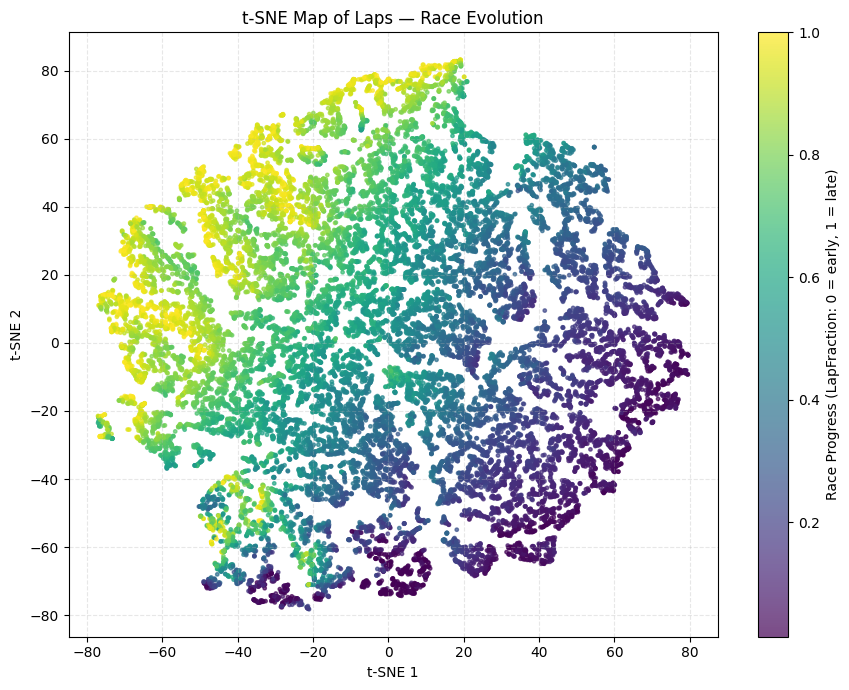

In [38]:
# ============================================================
# t-SNE MAP OF LAPS — VISUALIZING RACE EVOLUTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# ---------- 1. Make a working copy ----------
df_ts = df.copy()

# ---------- 2. Extra features for race evolution ----------

# Race progress (0 = start of race, 1 = end of race)
df_ts["LapFraction"] = (
    df_ts["lap"] / df_ts.groupby("raceId")["lap"].transform("max")
)

# Pace vs race median
df_ts["PaceDelta"] = (
    df_ts["LapTime_sec"] -
    df_ts.groupby("raceId")["LapTime_sec"].transform("median")
)

# Standardized pace per race
df_ts["PaceZ"] = df_ts.groupby("raceId")["LapTime_sec"].transform(
    lambda x: (x - x.mean()) / x.std()
)

# ---------- 3. Choose features for t-SNE ----------
tsne_features = [
    "LapTime_sec",
    "FuelLoadProxy",
    "LapsSincePit",
    "LapFraction",
    "PaceDelta",
    "PaceZ",
]

X = df_ts[tsne_features].dropna()

# Optional: downsample for speed (t-SNE is heavy)
max_points = 30000   # you can raise/lower this depending on speed
if len(X) > max_points:
    X = X.sample(max_points, random_state=42)

# Keep the matching rows
df_ts_vis = df_ts.loc[X.index].copy()

# ---------- 4. Scale features ----------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------- 5. Run t-SNE ----------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    init="random"
)

X_embedded = tsne.fit_transform(X_scaled)

df_ts_vis["TSNE1"] = X_embedded[:, 0]
df_ts_vis["TSNE2"] = X_embedded[:, 1]

# ---------- 6. Plot — colored by race progress ----------
plt.figure(figsize=(9,7))
scatter = plt.scatter(
    df_ts_vis["TSNE1"],
    df_ts_vis["TSNE2"],
    c=df_ts_vis["LapFraction"],
    cmap="viridis",
    s=6,
    alpha=0.7,
)
cbar = plt.colorbar(scatter)
cbar.set_label("Race Progress (LapFraction: 0 = early, 1 = late)")

plt.title("t-SNE Map of Laps — Race Evolution")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

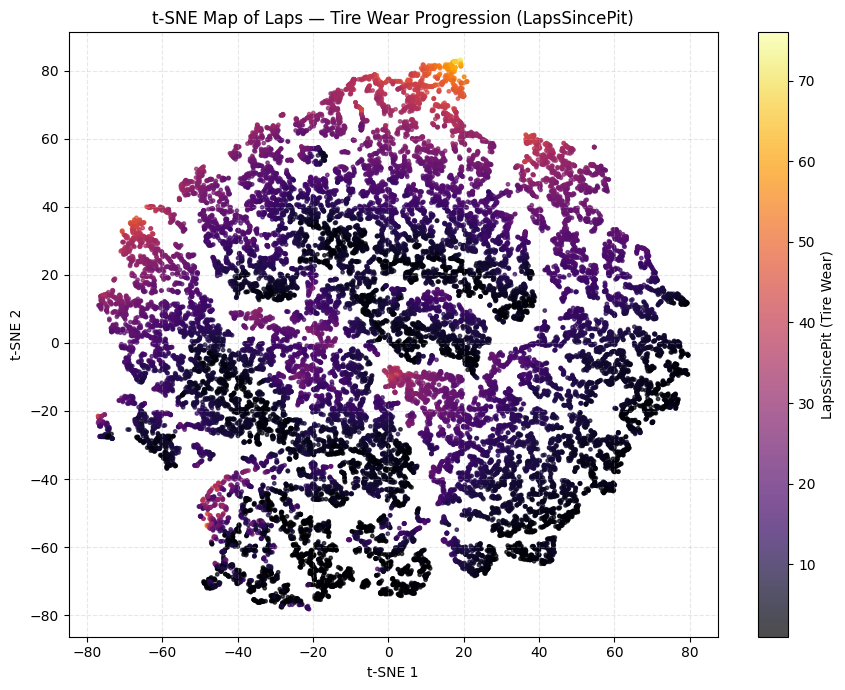

In [39]:
# ============================================================
# t-SNE MAP — COLORED BY LapsSincePit (TIRE WEAR PROGRESSION)
# ============================================================

plt.figure(figsize=(9,7))

scatter = plt.scatter(
    df_ts_vis["TSNE1"],
    df_ts_vis["TSNE2"],
    c=df_ts_vis["LapsSincePit"],
    cmap="inferno",   # great for heatmaps (dark = fresh tires, bright = worn tires)
    s=6,
    alpha=0.7
)

cbar = plt.colorbar(scatter)
cbar.set_label("LapsSincePit (Tire Wear)")

plt.title("t-SNE Map of Laps — Tire Wear Progression (LapsSincePit)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()